# Reliance Industries (RELIANCE) — Stock Return Prediction

**Assignment 2: Multi-Dimensional Return Forecasting and Portfolio Management**

---

## Objective

Predict the **next-day return** for Reliance Industries (RELIANCE) listed on NSE.

**Two targets:**
- `target_raw_return` — Next day's raw log return
- `target_residualized` — Next day's excess return over the sector

**Pipeline:**
```
Step 1  → Load Data (35 columns, ~1486 trading days)
Step 2  → Data Understanding (EDA + Visualisations)
Step 3  → Target Variable Analysis
Step 4  → Feature Engineering (Technical Indicators)
Step 5  → Data Leakage Audit
Step 6  → Missing Data & Winsorisation
Step 7  → Feature Selection (5 Methods)
Step 8  → Interaction Features & Rolling Standardisation
Step 9  → Train / Val / Test Split (70 / 15 / 15)
Step 10 → Model Training (12+ Models)
Step 11 → Results & Evaluation
```


In [121]:
import subprocess, sys
for pkg in ['lightgbm', 'xgboost', 'catboost', 'optuna', 'feature_engine', 'shap']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'])


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


---
## Step 1: Setup & Data Loading


In [122]:
# ── Standard libraries ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ── ML — Tree models ─────────────────────────────────────────────
import lightgbm as lgb
from lightgbm import LGBMRegressor, LGBMClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                              RandomForestClassifier)
try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False

# ── ML — Linear / SVM / NN ───────────────────────────────────────
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LassoCV

# ── Feature selection ────────────────────────────────────────────
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# ── Evaluation ───────────────────────────────────────────────────
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                             accuracy_score, confusion_matrix, classification_report)
from feature_engine.outliers import Winsorizer

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
RANDOM_STATE = 42
print('Libraries loaded')

Libraries loaded


In [123]:

# ── Stock config ────────────────────────────────────────────────
TICKER      = 'RELIANCE'
STOCK_NAME  = 'Reliance Industries'
SECTOR_NAME = 'Energy'
FILE_PATH   = 'Data_Final/Merged_Data/Merged_Only_Features_without_Sentiment_with_ffill/RELIANCE_merged_ffill.csv'

# ── Load ─────────────────────────────────────────────────────────
df = pd.read_csv(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df = df.loc[:, ~df.columns.duplicated()]

# Create lowercase/expected aliases so downstream code works
alias_map = {
    'Inflation_CPI': 'cpi',
    'RBI_Repo_Rate': 'repo_rate',
    'VIX_INDIA': 'india_vix',
    'USDINR': 'usd_inr',
    'CRUDE_BRENT': 'crude_brent',
    'CRUDE_WTI': 'crude_wti',
    'GOLD': 'gold',
    'US_10Y': 'us_10y',
    'NIFTY50_close': 'nifty50_close',
    'Real_Rate': 'real_rate',
    'Net_Income': 'net_income',
    'Profit_Margin': 'profit_margin',
    'Profit_Growth': 'profit_growth',
    'Revenue_Growth': 'revenue_growth',
    'Total_Assets': 'total_assets',
    'Total_Debt': 'total_debt',
    'Stockholders_Equity': 'stockholders_equity',
    'Debt_Equity': 'debt_equity',
    'Cash': 'cash'
}
for src_col, alias in alias_map.items():
    if src_col in df.columns and alias not in df.columns:
        df[alias] = df[src_col]

# Add empty placeholders for expected macro/flow columns if missing
expected_optional = ['tbill_91d','gsec_10y_yield','yield_curve_spread',
                     'cg_securities_cr','sg_securities_cr','fii_net_cr','dii_net_cr',
                     'usd_inr','eur_inr','gbp_inr','jpy_inr',
                     'crude_brent_return','crude_wti_return','gold_return']
for col in expected_optional:
    if col not in df.columns:
        df[col] = np.nan

# Ensure stock_log_return and target_raw_return exist
if 'stock_log_return' not in df.columns and 'log_return' in df.columns:
    df['stock_log_return'] = df['log_return']

if 'target_raw_return' not in df.columns:
    if 'stock_log_return' in df.columns:
        df['target_raw_return'] = df['stock_log_return'].shift(-1)
    elif 'log_return' in df.columns:
        df['target_raw_return'] = df['log_return'].shift(-1)
    elif 'return_pct' in df.columns:
        df['target_raw_return'] = df['return_pct'].shift(-1)
    else:
        raise ValueError('Cannot create target_raw_return — no return column found')

print(f'Shape  : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Period : {df["date"].min().date()} → {df["date"].max().date()}')
print()
print('Columns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')
df.tail()


Shape  : 1486 rows × 37 columns
Period : 2020-01-01 → 2025-12-30

Columns:
   1. date
   2. open
   3. high
   4. low
   5. close
   6. volume
   7. stock_log_return
   8. volume_change
   9. eps
  10. pe_ratio
  11. revenue
  12. revenue_growth
  13. net_income
  14. profit_margin
  15. profit_growth
  16. nifty50_return
  17. sector_return
  18. india_vix
  19. repo_rate
  20. tbill_91d
  21. gsec_10y_yield
  22. yield_curve_spread
  23. cpi
  24. cg_securities_cr
  25. sg_securities_cr
  26. fii_net_cr
  27. dii_net_cr
  28. usd_inr
  29. gbp_inr
  30. eur_inr
  31. jpy_inr
  32. crude_brent_return
  33. gold_return
  34. sentiment_score
  35. target_raw_return
  36. target_residualized
  37. crude_wti_return


,date,open,high,low,close,volume,stock_log_return,volume_change,eps,pe_ratio,revenue,revenue_growth,net_income,profit_margin,profit_growth,nifty50_return,sector_return,india_vix,repo_rate,tbill_91d,gsec_10y_yield,yield_curve_spread,cpi,cg_securities_cr,sg_securities_cr,fii_net_cr,dii_net_cr,usd_inr,gbp_inr,eur_inr,jpy_inr,crude_brent_return,gold_return,sentiment_score,target_raw_return,target_residualized,crude_wti_return
1481,2025-12-23,1580.900024,1580.900024,1568.099976,1570.699951,7506564,-0.002988,-0.305124,14.34,109.532772,2613880.0,8.9,194070.0,7.4,4.7,0.000181,0.005376,9.38,5.25,5.2780,6.67,1.3920,197.3,419534.944016,35366.372,-2346.9,52794.0,89.8314,121.1305,105.7393,57.54,0.004982,0.008558,0.147425,-0.007990,-0.004601,NaN
1482,2025-12-24,1572.699951,1575.699951,1553.599976,1558.199951,8815745,-0.007990,0.160761,14.34,108.661084,2613880.0,8.9,194070.0,7.4,4.7,-0.001340,-0.003389,9.19,5.25,5.2780,6.67,1.3920,197.3,419534.944016,35366.372,-2346.9,52794.0,89.7703,121.3694,105.9433,57.64,-0.002247,-0.000491,0.041741,0.000642,0.001676,NaN
1483,2025-12-26,1554.699951,1561.000000,1554.300049,1559.199951,2311495,0.000642,-1.338645,14.34,108.730819,2613880.0,8.9,194070.0,7.4,4.7,-0.003825,-0.001035,9.15,5.25,5.2579,6.65,1.3921,197.3,403599.238004,26613.944,-2346.9,52794.0,89.8296,121.2400,105.8522,57.50,-0.026043,0.010766,-0.043592,-0.008761,-0.003325,NaN
1484,2025-12-29,1554.900024,1558.099976,1543.599976,1545.599976,5972105,-0.008761,0.949205,14.34,107.782425,2613880.0,8.9,194070.0,7.4,4.7,-0.003855,-0.005436,9.72,5.25,5.2579,6.65,1.3921,197.3,403599.238004,26613.944,-2346.9,52794.0,89.9756,121.4053,105.8407,57.58,0.021211,-0.046088,-0.217576,-0.003760,-0.002185,NaN
1485,2025-12-30,1547.000000,1553.599976,1537.800049,1539.800049,8815884,-0.003760,0.389456,14.34,107.377967,2613880.0,8.9,194070.0,7.4,4.7,-0.000125,-0.001574,9.68,5.25,5.2579,6.65,1.3921,197.3,403599.238004,26613.944,-2346.9,52794.0,89.9429,121.5656,105.9269,57.64,-0.000323,0.010351,0.069186,NaN,NaN,NaN


---
## Step 2: Understanding the Raw Data

Dataset for **Reliance Industries** merges data from multiple sources:

| Source | Columns | Frequency |
|:---|:---|:---|
| Yahoo Finance | `open, high, low, close, volume` | Daily |
| Computed | `stock_log_return, volume_change` | Daily |
| Perplexity Finace | `eps, pe_ratio, revenue, net_income, profit_margin, …` | Quarterly |
| Yahoo | `nifty50_return, sector_return` | Daily |
| NSE India VIX | `india_vix` | Daily |
| RBI | `repo_rate, tbill_91d, gsec_10y_yield, yield_curve_spread` | Daily/Weekly |
| RBI | `cpi, cg_securities_cr, sg_securities_cr` | Monthly |
| Trendlyne | `fii_net_cr, dii_net_cr` | Monthly |
| RBI | `usd_inr, gbp_inr, eur_inr, jpy_inr` | Daily |
| Investing.com | `crude_brent_return, gold_return` | Daily |
| GDELT+ FinBERT | `sentiment_score` | Daily |


**Frequency alignment**: Quarterly fundamentals are forward-filled (merge_asof);
monthly macros/flows are forward-filled to daily;


In [124]:
print('=== DTYPES ===')
print(df.dtypes)
print()
print('=== MISSING VALUES ===')
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing': miss, 'Pct%': miss_pct})
print(miss_df[miss_df['Missing'] > 0].to_string())
print()
print('=== DESCRIPTIVE STATISTICS ===')
df.describe().round(4)

=== DTYPES ===
date                   datetime64[us]
open                          float64
high                          float64
low                           float64
close                         float64
volume                          int64
stock_log_return              float64
volume_change                 float64
eps                           float64
pe_ratio                      float64
revenue                       float64
revenue_growth                float64
net_income                    float64
profit_margin                 float64
profit_growth                 float64
nifty50_return                float64
sector_return                 float64
india_vix                     float64
repo_rate                     float64
tbill_91d                     float64
gsec_10y_yield                float64
yield_curve_spread            float64
cpi                           float64
cg_securities_cr              float64
sg_securities_cr              float64
fii_net_cr                    float

,date,open,high,low,close,volume,stock_log_return,volume_change,eps,pe_ratio,revenue,revenue_growth,net_income,profit_margin,profit_growth,nifty50_return,sector_return,india_vix,repo_rate,tbill_91d,gsec_10y_yield,yield_curve_spread,cpi,cg_securities_cr,sg_securities_cr,fii_net_cr,dii_net_cr,usd_inr,gbp_inr,eur_inr,jpy_inr,crude_brent_return,gold_return,sentiment_score,target_raw_return,target_residualized,crude_wti_return
count,1486,1486.0000,1486.0000,1486.0000,1486.0000,1.486000e+03,1486.0000,1486.0000,1486.0000,1486.0000,1.486000e+03,1486.0000,1486.0000,1486.0000,1486.0000,1486.0000,1486.0000,1486.0000,1486.0000,1486.0000,1486.0000,1486.0000,1486.0000,1.486000e+03,1486.000,1486.0000,1486.0000,1486.0000,1486.0000,1486.0000,1486.0000,1486.0000,1486.0000,1486.0000,1485.0000,1469.0000,0.0
mean,2022-12-29 01:34:57.981157,1147.8420,1158.9630,1136.2651,1147.1879,1.812902e+07,0.0006,NaN,11.5876,100.4946,1.964823e+06,3.8186,155193.8358,8.1703,5.9367,0.0005,0.0006,17.4720,5.3268,5.2434,6.7217,1.4783,174.9908,3.943509e+05,29444.255,-16325.5242,24828.7306,79.9883,103.0555,88.8528,61.5821,0.0000,0.0008,0.0292,0.0006,0.0000,NaN
min,2020-01-01 00:00:00,409.8649,424.9854,391.7247,395.4825,0.000000e+00,-0.1410,-inf,4.8900,43.3643,8.825300e+05,-35.5000,63480.0000,4.6000,-46.4000,-0.1390,-0.1331,9.1500,4.0000,2.9292,5.7268,0.0154,148.6000,1.369094e+05,6321.144,-114445.9000,-37293.5000,70.8115,86.6153,77.2522,51.6200,-0.2798,-0.0591,-0.7219,-0.1410,-0.0650,NaN
25%,2021-06-29 06:00:00,997.7755,1009.9262,985.4535,994.7362,9.584944e+06,-0.0084,-0.2731,10.1800,89.6487,1.495750e+06,-2.0000,132330.0000,7.4000,-13.9000,-0.0042,-0.0061,12.9400,4.0000,3.5202,6.3300,0.3263,160.6250,2.778604e+05,19922.442,-41346.4000,2067.2000,74.7643,98.3234,85.4584,57.1500,-0.0110,-0.0042,-0.0022,-0.0084,-0.0066,NaN
50%,2022-12-26 12:00:00,1161.4039,1169.9425,1150.9649,1161.1835,1.332284e+07,0.0007,-0.0020,11.8300,99.3973,2.113120e+06,4.8000,160110.0000,7.7000,4.7000,0.0009,0.0011,15.4300,5.5000,5.4597,6.7600,1.0988,176.5000,3.646540e+05,26188.820,-6015.3000,25017.0000,81.9639,102.1555,88.5558,59.7000,0.0008,0.0011,0.0054,0.0007,-0.0003,NaN
75%,2024-07-02 18:00:00,1318.7082,1323.0907,1300.4312,1316.4219,2.037365e+07,0.0085,0.2697,13.7000,108.7352,2.317840e+06,8.9000,185400.0000,8.7500,11.6750,0.0063,0.0085,20.0800,6.5000,6.6462,7.1575,2.7421,187.7000,4.713139e+05,36125.420,2735.0000,44186.3000,83.5229,106.3358,90.5189,66.6775,0.0132,0.0067,0.0591,0.0085,0.0057,NaN
max,2025-12-30 00:00:00,1592.6620,1596.9802,1573.8513,1589.1382,1.426834e+08,0.1373,inf,14.3400,162.4813,2.613880e+06,26.9000,194070.0000,15.0000,111.2000,0.0840,0.0828,83.6100,6.5000,7.0508,7.5899,3.4326,197.3000,1.007336e+06,95202.096,48223.9000,107254.7000,91.0202,121.6103,106.9506,72.0600,0.3212,0.0578,0.7228,0.1373,0.0854,NaN
std,NaN,240.0890,240.3140,240.1145,240.3457,1.516583e+07,0.0178,NaN,2.3660,17.0884,5.032534e+05,12.5124,33483.2589,1.9170,29.3571,0.0115,0.0145,7.7204,1.0707,1.4545,0.4870,1.1270,15.5677,1.685781e+05,13100.345,32377.7916,29205.4286,5.1509,7.1219,5.8259,5.5298,0.0278,0.0107,0.1355,0.0178,0.0118,NaN


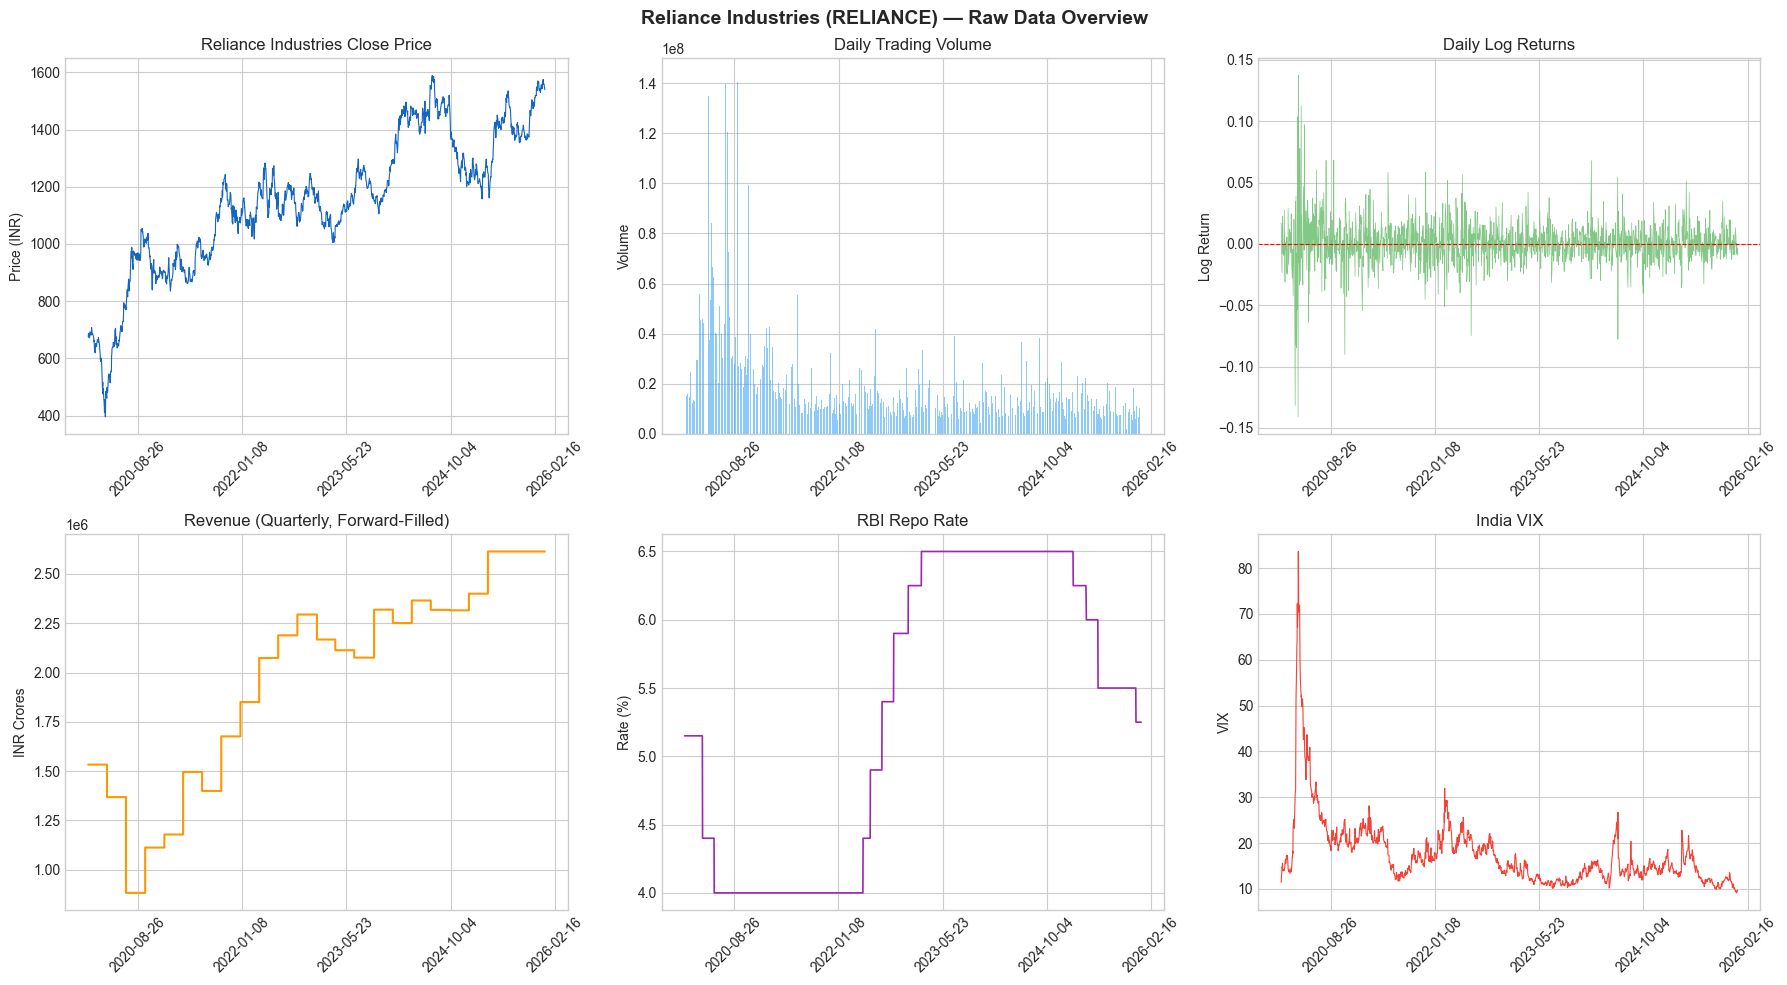

In [125]:
# ── Viz 1: OHLCV, Fundamentals, Macro ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].plot(df['date'], df['close'], color='#1565C0', lw=0.8)
axes[0, 0].set_title(f'{STOCK_NAME} Close Price')
axes[0, 0].set_ylabel('Price (INR)')

axes[0, 1].bar(df['date'], df['volume'], color='#42A5F5', alpha=0.6, width=1)
axes[0, 1].set_title('Daily Trading Volume')
axes[0, 1].set_ylabel('Volume')

axes[0, 2].plot(df['date'], df['stock_log_return'], color='#66BB6A', lw=0.5, alpha=0.8)
axes[0, 2].axhline(0, color='red', ls='--', lw=0.8)
axes[0, 2].set_title('Daily Log Returns')
axes[0, 2].set_ylabel('Log Return')

axes[1, 0].step(df['date'], df['revenue'], color='#FF9800', where='post', lw=1.5)
axes[1, 0].set_title('Revenue (Quarterly, Forward-Filled)')
axes[1, 0].set_ylabel('INR Crores')

axes[1, 1].plot(df['date'], df['repo_rate'], color='#9C27B0', lw=1.2)
axes[1, 1].set_title('RBI Repo Rate')
axes[1, 1].set_ylabel('Rate (%)')

axes[1, 2].plot(df['date'], df['india_vix'], color='#F44336', lw=0.8)
axes[1, 2].set_title('India VIX')
axes[1, 2].set_ylabel('VIX')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))

plt.suptitle(f'{STOCK_NAME} ({TICKER}) — Raw Data Overview',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

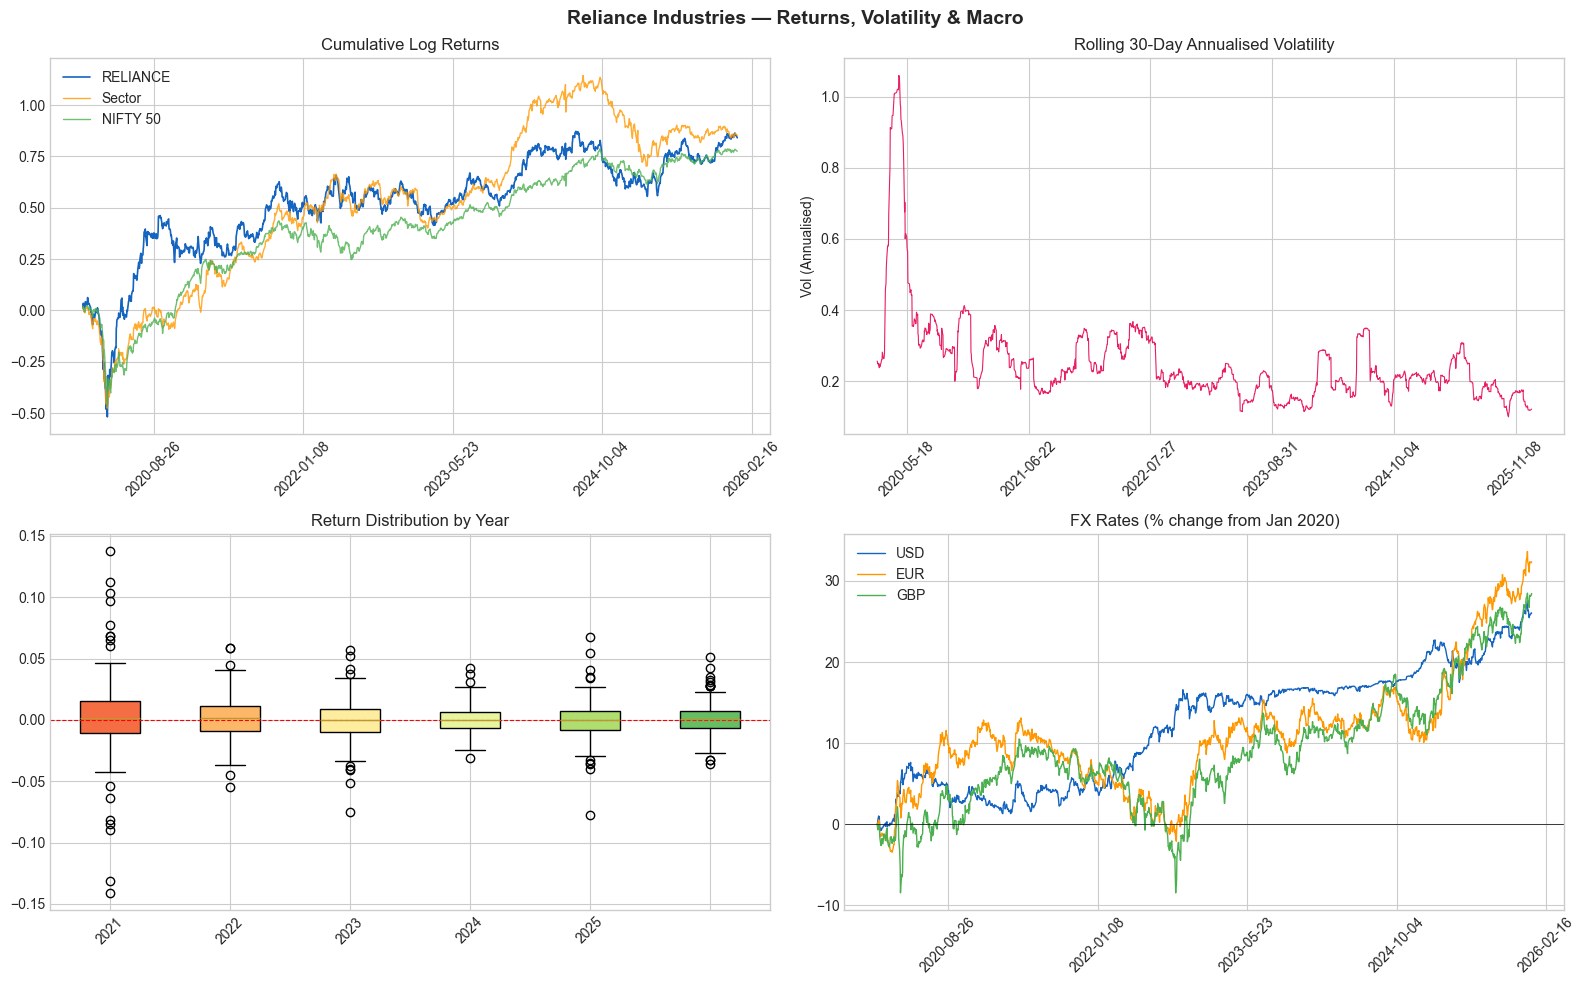

In [126]:
# ── Viz 2: Returns, Volatility, FX ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Cumulative returns: Stock vs Sector vs Nifty
cum_stock  = df['stock_log_return'].fillna(0).cumsum()
cum_sector = df['sector_return'].fillna(0).cumsum()
cum_nifty  = df['nifty50_return'].fillna(0).cumsum()
axes[0, 0].plot(df['date'], cum_stock,  label=TICKER,      color='#1565C0', lw=1.2)
axes[0, 0].plot(df['date'], cum_sector, label='Sector',    color='#FF9800', lw=1, alpha=0.8)
axes[0, 0].plot(df['date'], cum_nifty,  label='NIFTY 50',  color='#4CAF50', lw=1, alpha=0.8)
axes[0, 0].set_title('Cumulative Log Returns')
axes[0, 0].legend()

# Rolling volatility
roll_vol = df['stock_log_return'].rolling(30).std() * np.sqrt(252)
axes[0, 1].plot(df['date'], roll_vol, color='#E91E63', lw=0.8)
axes[0, 1].set_title('Rolling 30-Day Annualised Volatility')
axes[0, 1].set_ylabel('Vol (Annualised)')

# Return distribution by year
df['_year'] = df['date'].dt.year
yrs = sorted(df['_year'].unique())
bp  = axes[1, 0].boxplot(
    [df[df['_year'] == yr]['stock_log_return'].dropna() for yr in yrs],
    labels=[str(y) for y in yrs], patch_artist=True)
for patch, c in zip(bp['boxes'],
                    plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(yrs)))):
    patch.set_facecolor(c)
axes[1, 0].axhline(0, color='red', ls='--', lw=0.8)
axes[1, 0].set_title('Return Distribution by Year')

# FX normalised
for col, lbl, clr in [('usd_inr','USD','#1565C0'),('eur_inr','EUR','#FF9800'),('gbp_inr','GBP','#4CAF50')]:
    norm = (df[col] - df[col].iloc[0]) / df[col].iloc[0] * 100
    axes[1, 1].plot(df['date'], norm, label=lbl, color=clr, lw=1)
axes[1, 1].axhline(0, color='black', lw=0.5)
axes[1, 1].set_title('FX Rates (% change from Jan 2020)')
axes[1, 1].legend()

df = df.drop(columns=['_year'], errors='ignore')
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))
plt.suptitle(f'{STOCK_NAME} — Returns, Volatility & Macro', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

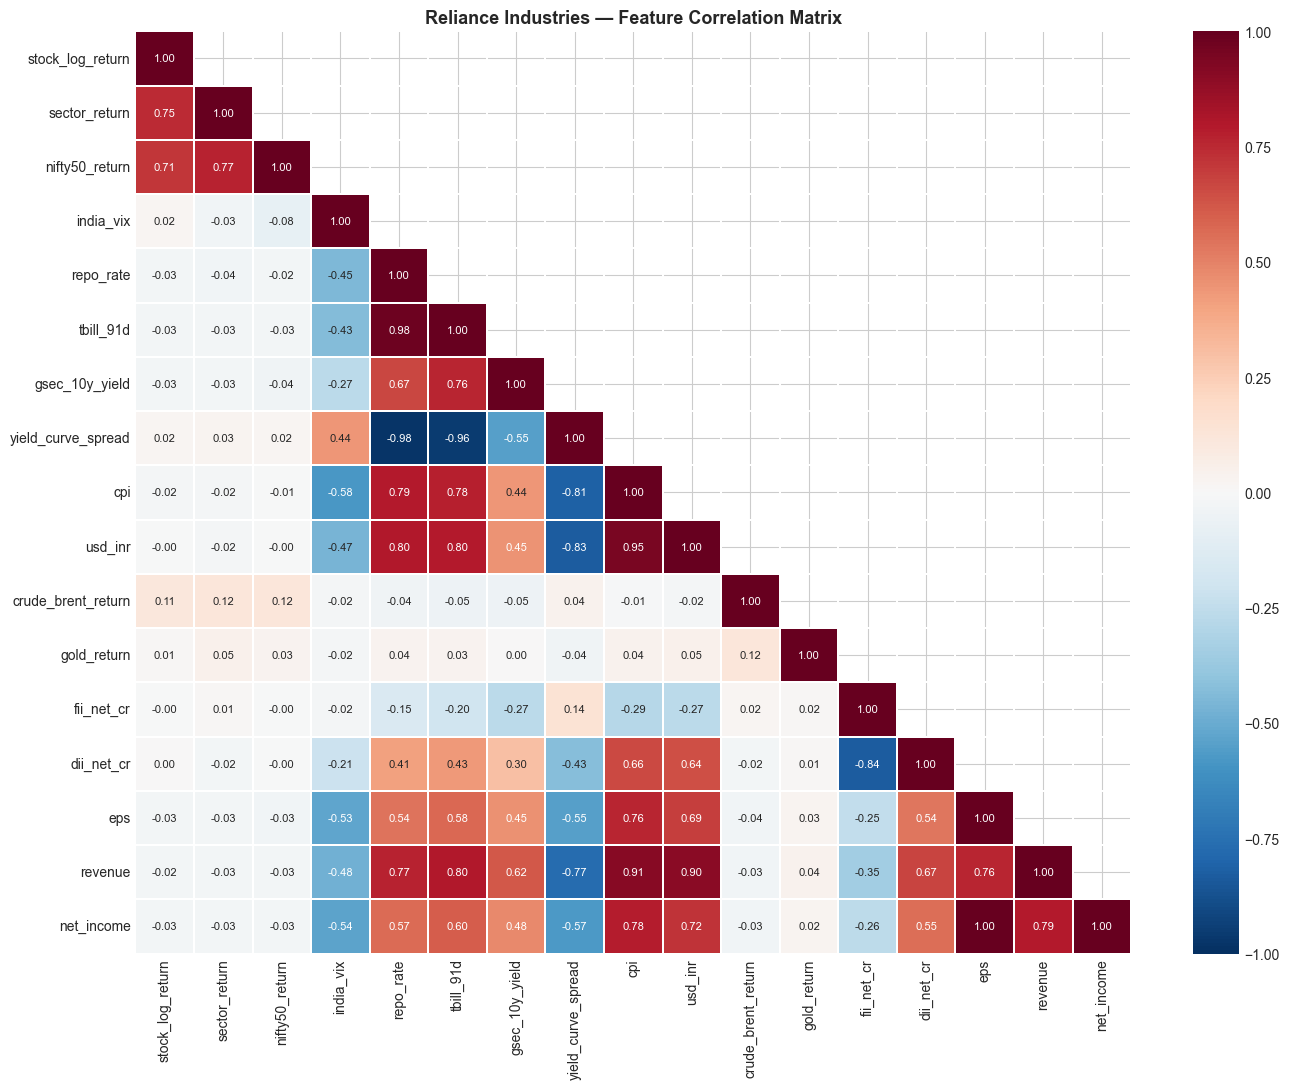

In [127]:
# ── Viz 3: Correlation heatmap ───────────────────────────────────
key_cols = ['stock_log_return', 'sector_return', 'nifty50_return', 'india_vix',
            'repo_rate', 'tbill_91d', 'gsec_10y_yield', 'yield_curve_spread',
            'cpi', 'usd_inr', 'crude_brent_return', 'gold_return',
            'fii_net_cr', 'dii_net_cr', 'eps', 'revenue', 'net_income']
key_cols = [c for c in key_cols if c in df.columns]
corr = df[key_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.3, ax=ax, annot_kws={'size': 8},
            vmin=-1, vmax=1)
ax.set_title(f'{STOCK_NAME} — Feature Correlation Matrix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

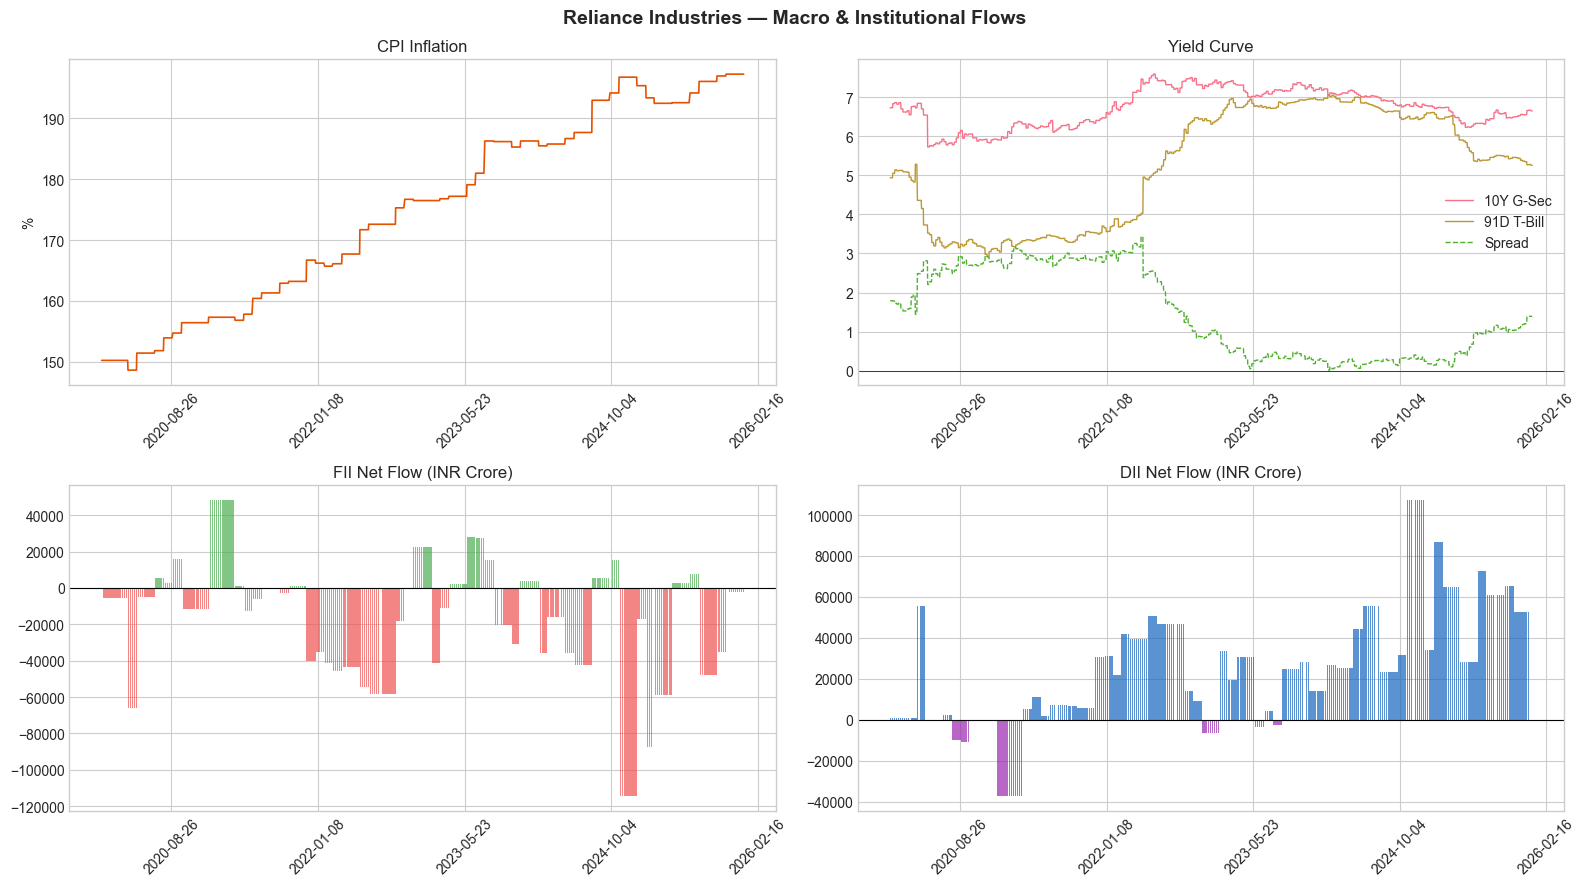

In [128]:
# ── Viz 4: Macro, Yield Curve, FII/DII ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

axes[0, 0].plot(df['date'], df['cpi'], color='#E65100', lw=1.2)
axes[0, 0].set_title('CPI Inflation')
axes[0, 0].set_ylabel('%')

axes[0, 1].plot(df['date'], df['gsec_10y_yield'], label='10Y G-Sec', lw=1)
axes[0, 1].plot(df['date'], df['tbill_91d'],      label='91D T-Bill', lw=1)
axes[0, 1].plot(df['date'], df['yield_curve_spread'], label='Spread', ls='--', lw=1)
axes[0, 1].axhline(0, color='black', lw=0.5)
axes[0, 1].set_title('Yield Curve')
axes[0, 1].legend()

fii_colors = df['fii_net_cr'].fillna(0).apply(lambda x: '#4CAF50' if x >= 0 else '#EF5350')
axes[1, 0].bar(df['date'], df['fii_net_cr'].fillna(0), color=fii_colors, alpha=0.7, width=1)
axes[1, 0].axhline(0, color='black', lw=0.8)
axes[1, 0].set_title('FII Net Flow (INR Crore)')

dii_colors = df['dii_net_cr'].fillna(0).apply(lambda x: '#1565C0' if x >= 0 else '#9C27B0')
axes[1, 1].bar(df['date'], df['dii_net_cr'].fillna(0), color=dii_colors, alpha=0.7, width=1)
axes[1, 1].axhline(0, color='black', lw=0.8)
axes[1, 1].set_title('DII Net Flow (INR Crore)')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))
plt.suptitle(f'{STOCK_NAME} — Macro & Institutional Flows',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 3: Target Variable Analysis

| Target | Formula | Interpretation |
|:---|:---|:---|
| `target_raw_return` | `stock_log_return.shift(-1)` | Next day's raw log return |
| `target_residualized` | `(stock_log_return − sector_return).shift(-1)` | Next day excess return |

- **Positive residualized** → Stock outperforms sector (BUY signal)
- **Negative residualized** → Stock underperforms sector (SELL signal)


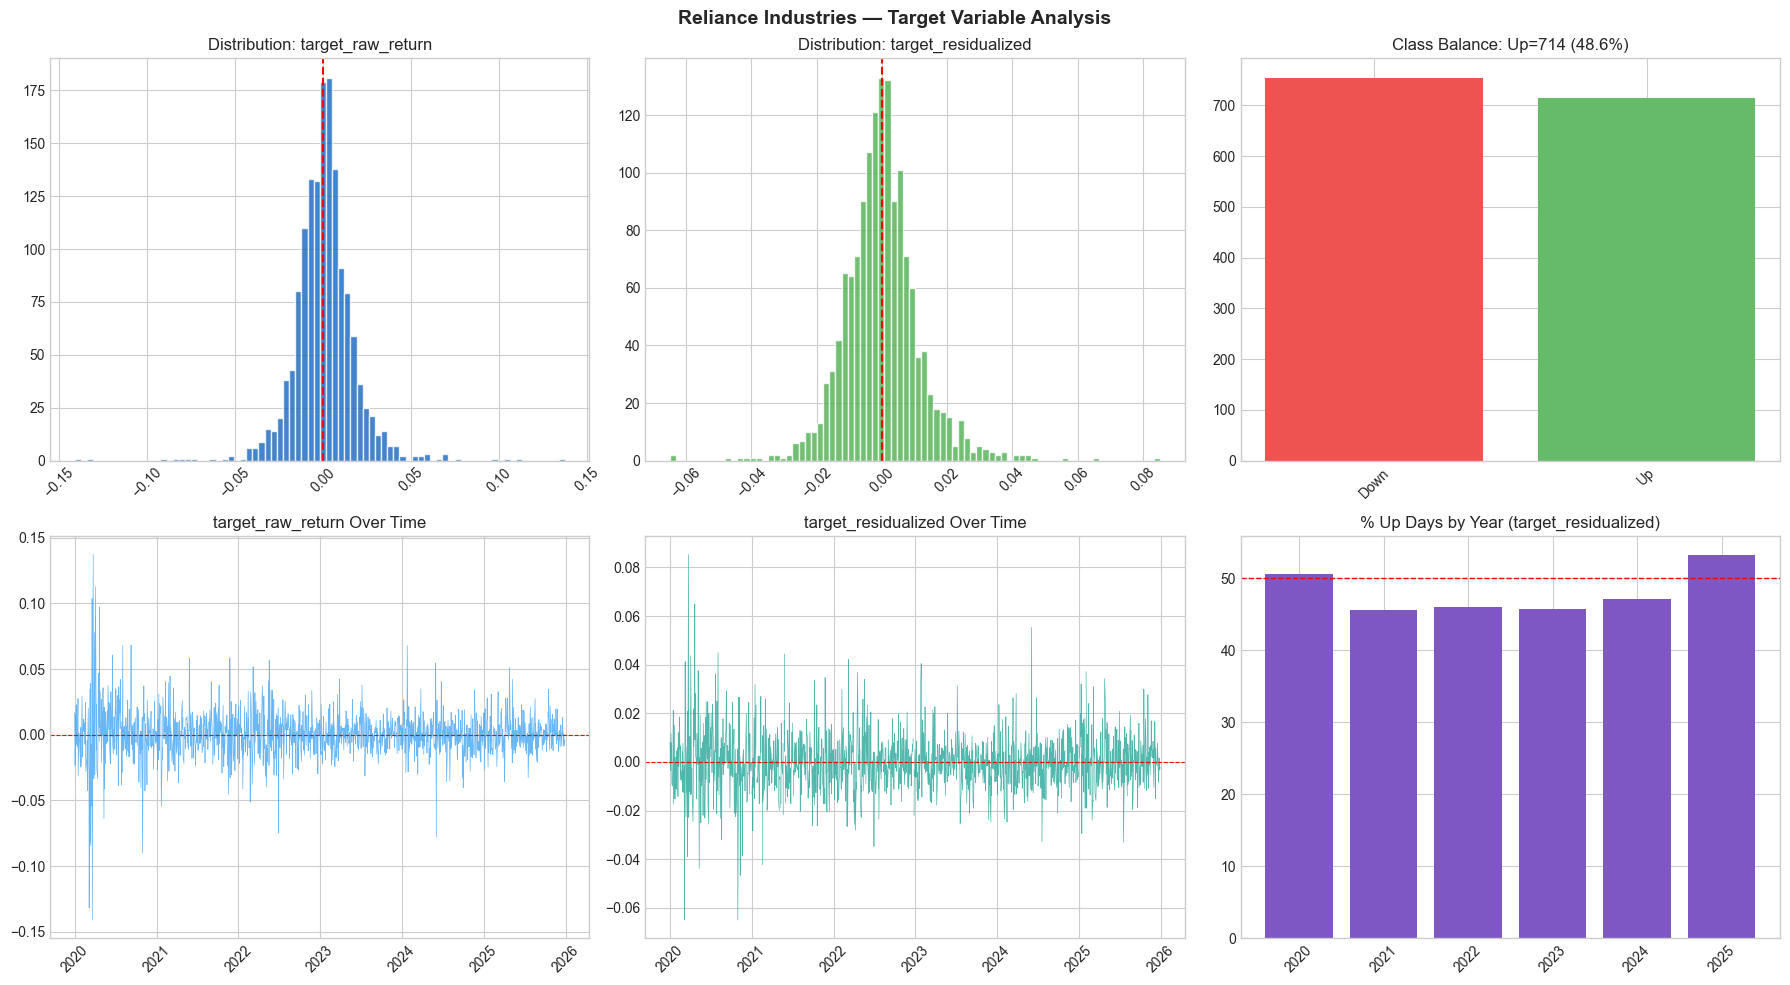

target_raw_return   — Mean: 0.00056, Std: 0.01778
target_residualized — Mean: 0.00000, Std: 0.01180


In [129]:
target_r   = df['target_raw_return'].dropna()
target_res = df['target_residualized'].dropna()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Distributions
axes[0, 0].hist(target_r,   bins=80, color='#1565C0', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(0, color='red', ls='--', lw=1.5)
axes[0, 0].set_title('Distribution: target_raw_return')

axes[0, 1].hist(target_res, bins=80, color='#4CAF50', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(0, color='red', ls='--', lw=1.5)
axes[0, 1].set_title('Distribution: target_residualized')

# Class balance
up, down = (target_res >= 0).sum(), (target_res < 0).sum()
axes[0, 2].bar(['Down', 'Up'], [down, up], color=['#EF5350', '#66BB6A'])
axes[0, 2].set_title(f'Class Balance: Up={up} ({up/(up+down)*100:.1f}%)')

# Time series
axes[1, 0].plot(df['date'], df['target_raw_return'],   color='#42A5F5', lw=0.5, alpha=0.8)
axes[1, 0].axhline(0, color='red', ls='--', lw=0.8)
axes[1, 0].set_title('target_raw_return Over Time')

axes[1, 1].plot(df['date'], df['target_residualized'], color='#26A69A', lw=0.5, alpha=0.8)
axes[1, 1].axhline(0, color='red', ls='--', lw=0.8)
axes[1, 1].set_title('target_residualized Over Time')

# % Up days per year
df['_year'] = df['date'].dt.year
df['_up']   = (df['target_residualized'] >= 0).astype(int)
up_pct = df.groupby('_year')['_up'].mean() * 100
axes[1, 2].bar(up_pct.index.astype(str), up_pct.values, color='#7E57C2')
axes[1, 2].axhline(50, color='red', ls='--', lw=1)
axes[1, 2].set_title('% Up Days by Year (target_residualized)')

df = df.drop(columns=['_year', '_up'], errors='ignore')
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)
plt.suptitle(f'{STOCK_NAME} — Target Variable Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'target_raw_return   — Mean: {target_r.mean():.5f}, Std: {target_r.std():.5f}')
print(f'target_residualized — Mean: {target_res.mean():.5f}, Std: {target_res.std():.5f}')

---
## Step 4: Feature Engineering — Technical Indicators (Implemented)

| Indicator | Type | What It Measures |
|:---|:---|:---|
| SMA 20/50 | Trend | Simple moving averages |
| EMA 12/26 | Trend | Exponential (recent-weighted) moving averages |
| MACD / Signal / Histogram | Momentum | EMA-12 minus EMA-26 crossover structure |
| RSI 14 | Momentum | Overbought / oversold oscillator |
| Bollinger Bands (Mid/Upper/Lower) + BB_pct | Volatility | Price position within 2σ channels |
| ATR 14 | Volatility | Average True Range (range-based volatility) |
| OBV | Volume | On-Balance Volume trend |
| volume_z | Volume | Z-score vs 20-day volume mean |
| Buying / Selling Pressure | Price Action | Close position in daily high-low range |
| Lagged returns (1, 3) | Momentum | Past log returns (short-memory autocorrelation) |
| Lagged volume (1, 3) | Volume | Past volume (attention proxy) |
| Lagged sector return (1) | Market | Recent sector momentum |


In [130]:
def create_technical_features(df):
    df = df.copy()
    eps = 1e-9

    # Minimal technical feature set to reduce compute
    df['Buying_Pressure']  = (df['close'] - df['low'])  / (df['high'] - df['low'] + eps)
    df['Selling_Pressure'] = (df['high'] - df['close']) / (df['high'] - df['low'] + eps)

    # Moving averages
    for w in [20, 50]:
        df[f'SMA_{w}'] = df['close'].rolling(w).mean()
    for sp in [12, 26]:
        df[f'EMA_{sp}'] = df['close'].ewm(span=sp, adjust=False).mean()

    # MACD trio
    df['MACD']        = df['EMA_12'] - df['EMA_26']
    df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_hist']   = df['MACD'] - df['MACD_signal']

    # RSI 14
    delta = df['close'].diff()
    gain  = delta.where(delta > 0, 0).rolling(14).mean()
    loss  = (-delta.where(delta < 0, 0)).rolling(14).mean()
    df['RSI_14'] = 100 - (100 / (1 + gain / (loss + eps)))

    # Bollinger Bands + %
    bb_mid = df['close'].rolling(20).mean()
    bb_std = df['close'].rolling(20).std()
    bb_up  = bb_mid + 2 * bb_std
    bb_lo  = bb_mid - 2 * bb_std

    df['BB_mid']   = bb_mid
    df['BB_upper'] = bb_up
    df['BB_lower'] = bb_lo
    df['BB_pct']   = (df['close'] - bb_lo) / (bb_up - bb_lo + eps)

    # ATR 14
    tr  = pd.concat([
        df['high'] - df['low'],
        (df['high'] - df['close'].shift(1)).abs(),
        (df['low']  - df['close'].shift(1)).abs()
    ], axis=1).max(axis=1)
    df['ATR_14'] = tr.rolling(14).mean()

    # Volume/flow
    df['OBV'] = (df['volume'] * np.sign(df['close'].diff())).cumsum()
    df['volume_z'] = ((df['volume'] - df['volume'].rolling(20).mean())
                      / (df['volume'].rolling(20).std() + eps))

    # Light lags
    for lag in [1, 3]:
        df[f'return_lag{lag}'] = df['stock_log_return'].shift(lag)
        df[f'volume_lag{lag}'] = df['volume'].shift(lag)
    df['sector_lag1'] = df['sector_return'].shift(1)

    return df

df = create_technical_features(df)
print(f'Technical features created. Total columns: {len(df.columns)}')


Technical features created. Total columns: 59


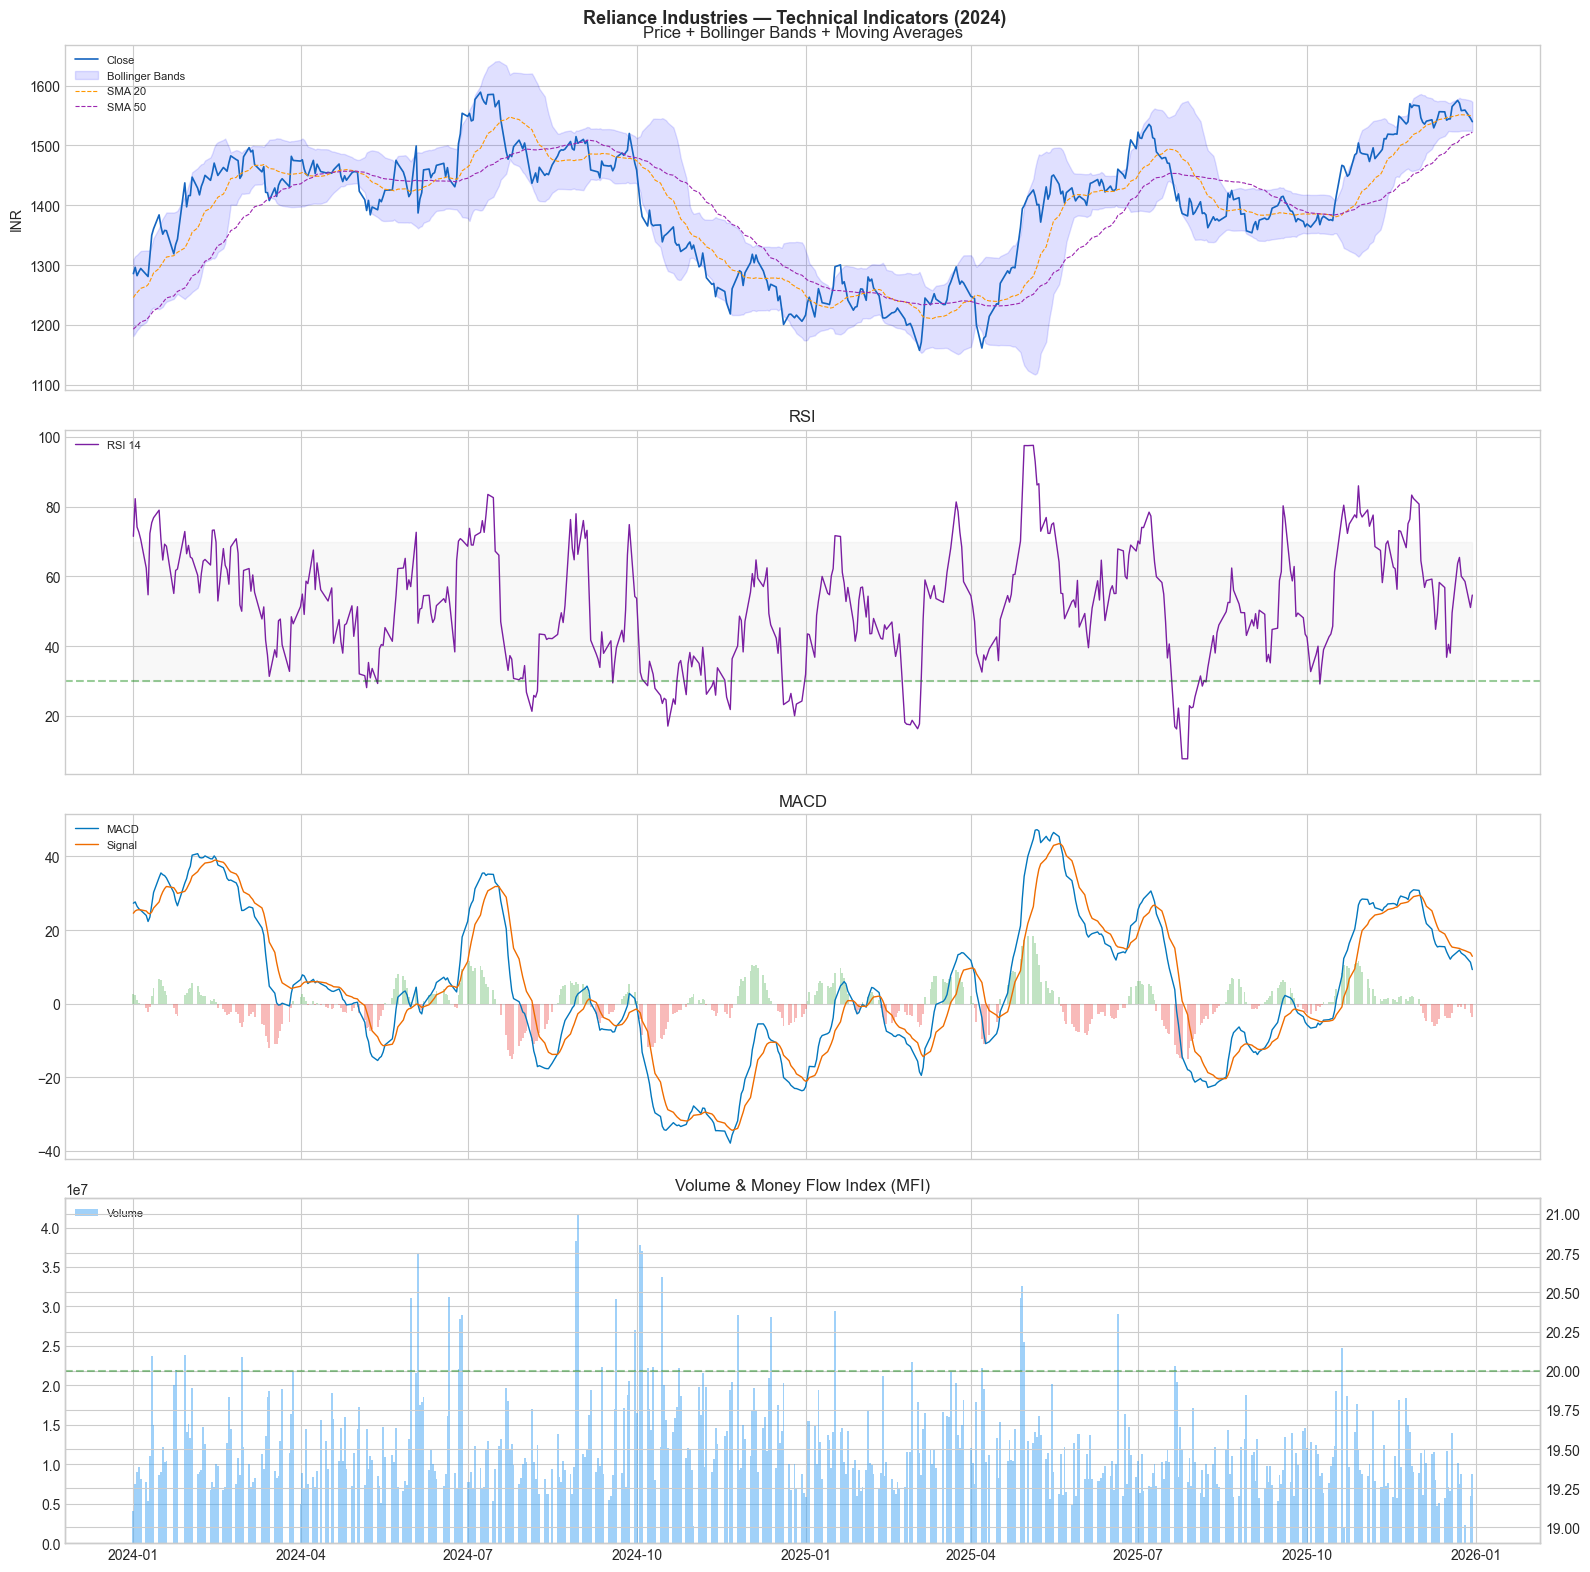

In [131]:
# ── Viz 5: Technical Indicators (2024 subset) ────────────────────
recent = df[df['date'] >= '2024-01-01'].copy()

fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)

# Price + BB + SMA
axes[0].plot(recent['date'], recent['close'], label='Close', color='#1565C0', lw=1.2)
axes[0].fill_between(recent['date'], recent['BB_lower'], recent['BB_upper'],
                     alpha=0.12, color='blue', label='Bollinger Bands')
axes[0].plot(recent['date'], recent['SMA_20'], '--', color='#FF9800', lw=0.8, label='SMA 20')
axes[0].plot(recent['date'], recent['SMA_50'], '--', color='#9C27B0', lw=0.8, label='SMA 50')
axes[0].legend(loc='upper left', fontsize=8)
axes[0].set_title('Price + Bollinger Bands + Moving Averages')
axes[0].set_ylabel('INR')

# RSI
axes[1].plot(recent['date'], recent['RSI_14'],  color='#7B1FA2', lw=1,   label='RSI 14')
axes[1].axhline(30, color='green', ls='--', alpha=0.4)
axes[1].fill_between(recent['date'], 30, 70, alpha=0.05, color='gray')
axes[1].set_title('RSI')
axes[1].legend(loc='upper left', fontsize=8)

# MACD
axes[2].plot(recent['date'], recent['MACD'],        label='MACD',   color='#0277BD', lw=1)
axes[2].plot(recent['date'], recent['MACD_signal'], label='Signal', color='#EF6C00', lw=1)
hist_c = ['#66BB6A' if v >= 0 else '#EF5350' for v in recent['MACD_hist']]
axes[2].bar(recent['date'], recent['MACD_hist'], color=hist_c, alpha=0.4, width=1)
axes[2].set_title('MACD')
axes[2].legend(loc='upper left', fontsize=8)

# Volume
ax4b = axes[3].twinx()
axes[3].bar(recent['date'], recent['volume'], color='#42A5F5', alpha=0.5, width=1, label='Volume')
ax4b.axhline(20, color='green', ls='--', alpha=0.4)
axes[3].set_title('Volume & Money Flow Index (MFI)')
axes[3].legend(loc='upper left', fontsize=8)
ax4b.legend(loc='upper right', fontsize=8)

plt.suptitle(f'{STOCK_NAME} — Technical Indicators (2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

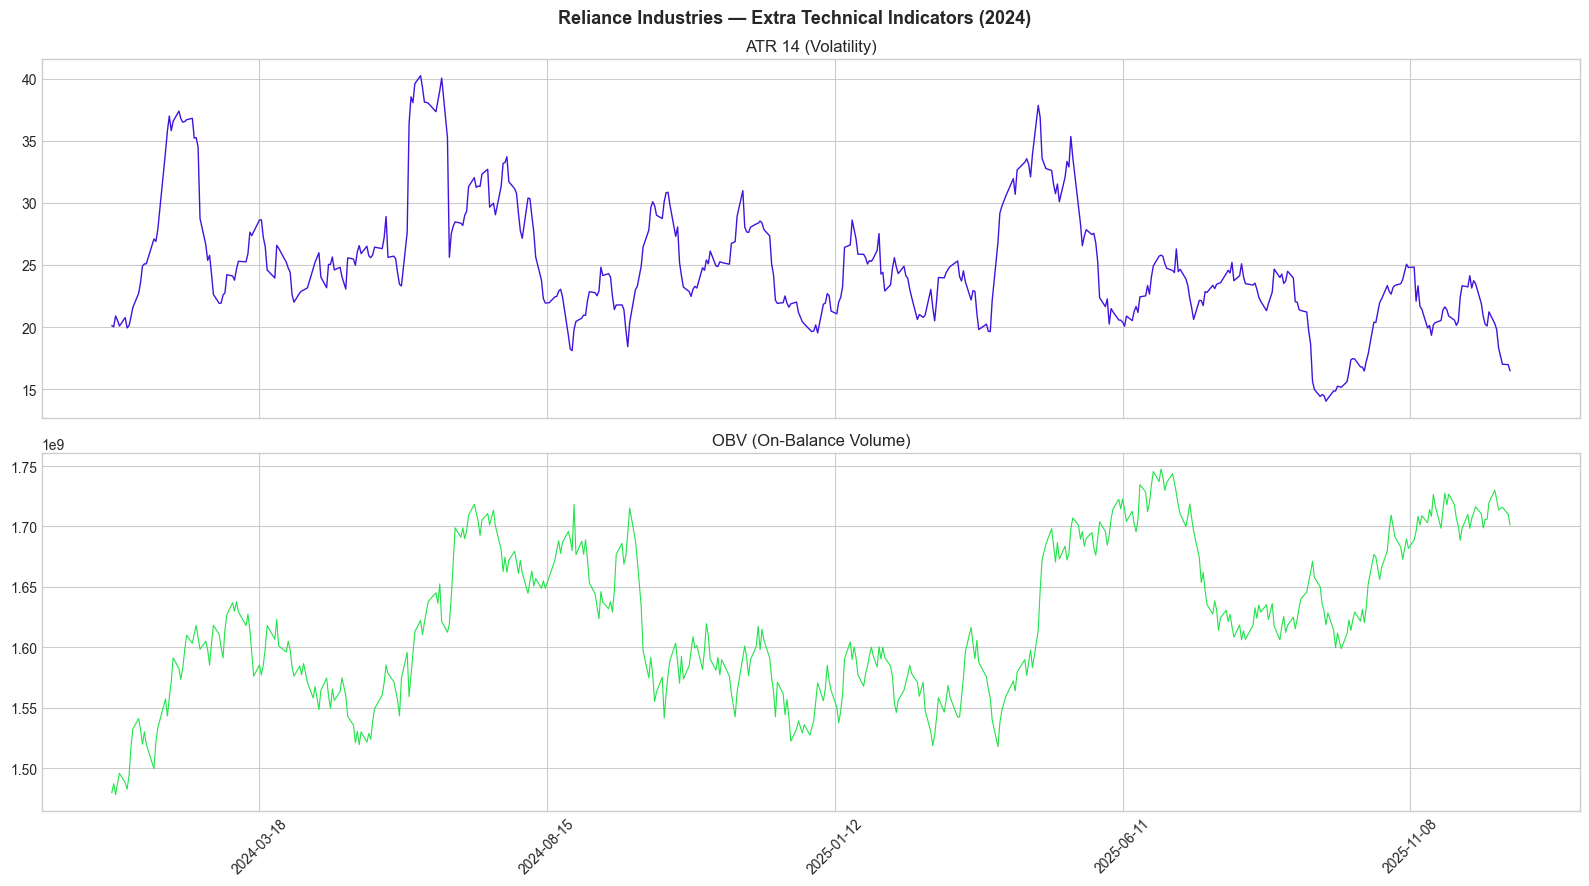

In [132]:
# ── Viz 6: ATR, OBV ───────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

axes[0].plot(recent['date'], recent['ATR_14'], color="#4213DD", lw=1)
axes[0].set_title('ATR 14 (Volatility)')

axes[1].plot(recent['date'], recent['OBV'], color="#22E349", lw=0.8)
axes[1].set_title('OBV (On-Balance Volume)')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))

plt.suptitle(f'{STOCK_NAME} — Extra Technical Indicators (2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 5: Data Leakage Audit

**Leakage** = using information not available at prediction time.

| Feature | Why Excluded |
|:---|:---|
| `close, high, low, open` | Non-stationary price levels |
| `stock_log_return` | Today's return — predicting tomorrow's |
| `sector_return` | Today's sector return (part of target formula) |
| `nifty50_return` | Today's broad market return |
| `target_raw_return` | Alternative target — cannot use as input |
| `target_residualized` | Primary target — cannot use as input |

**Kept features:**  volume, volume_change, all technical indicators (lag-based),
lagged returns, all macro/fundamental columns.


In [133]:
META_COLS   = ['date']
TARGET_COLS = ['target_residualized', 'target_raw_return', 'target_direction',
               'sector_return', 'nifty50_return', 'stock_log_return', 'log_return']
LEAKY_COLS  = ['close', 'high', 'low', 'open', 'return_pct']
REDUNDANT_COLS = ['BB_mid', 'Selling_Pressure', 'tbill_91d', 'gsec_10y_yield']

# Never use in model
EXCLUDE = LEAKY_COLS + REDUNDANT_COLS

FUNDAMENTAL_COLS = ['eps', 'pe_ratio', 'revenue', 'revenue_growth',
                    'net_income', 'profit_margin', 'profit_growth',
                    'total_assets', 'total_debt', 'stockholders_equity', 'cash', 'debt_equity']
MACRO_COLS       = ['cpi', 'yield_curve_spread', 'repo_rate', 'india_vix', 'real_rate', 'us_10y']
FLOW_COLS        = ['cg_securities_cr', 'sg_securities_cr',
                    'fii_net_cr', 'dii_net_cr']
FOREX_COLS       = ['usd_inr', 'eur_inr', 'gbp_inr', 'jpy_inr']
COMMOD_COLS      = ['crude_brent_return', 'gold_return']
VOLUME_COLS     = ['volume', 'volume_change']
SENTIMENT_COLS   = ['sentiment_score']  # Placeholder if sentiment features are added later

# Keep all of these in final dataset (meta + targets + always-keep features)
INCLUDED_COLS = META_COLS + TARGET_COLS + FUNDAMENTAL_COLS + MACRO_COLS + FLOW_COLS + FOREX_COLS + COMMOD_COLS + VOLUME_COLS + SENTIMENT_COLS

SMA_COLS        = [c for c in df.columns if c.startswith('SMA_')]
EMA_COLS        = [c for c in df.columns if c.startswith('EMA_')]
MACD_COLS       = [c for c in df.columns if c.startswith('MACD')]
RSI_COLS        = [c for c in df.columns if c.startswith('RSI_')]
BB_COLS         = [c for c in df.columns if c.startswith('BB_')]
ATR_COLS        = [c for c in df.columns if c.startswith('ATR_')]
BUYING_PRESSURE_COLS = [c for c in df.columns if c.startswith('Buying_Pressure')]
OBV_COLS        = [c for c in df.columns if c.startswith('OBV')]
VOLUME_Z_COLS   = [c for c in df.columns if c.startswith('volume_z')]
RETURN_LAG_COLS = [c for c in df.columns if c.startswith('return_lag')]
VOLUME_LAG_COLS = [c for c in df.columns if c.startswith('volume_lag')]
SECTOR_LAG_COLS = [c for c in df.columns if c.startswith('sector_lag')]

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Feature selection pool = numeric columns not in excluded and not in INCLUDED_COLS
candidate_features = [c for c in numeric_cols if c not in EXCLUDE and c not in INCLUDED_COLS]

print(f'Total numeric columns         : {len(numeric_cols)}')
print(f'Never-use cols (leaky+redund) : {len(EXCLUDE)}')
print(f'Included cols (final dataset) : {len(INCLUDED_COLS)}')
print(f'Candidate features (FS pool)  : {len(candidate_features)}')
print()
print('CANDIDATE FEATURES:')
for i, f in enumerate(candidate_features, 1):
    print(f'  {i:2d}. {f}')

Total numeric columns         : 58
Never-use cols (leaky+redund) : 9
Included cols (final dataset) : 39
Candidate features (FS pool)  : 21

CANDIDATE FEATURES:
   1. crude_wti_return
   2. Buying_Pressure
   3. SMA_20
   4. SMA_50
   5. EMA_12
   6. EMA_26
   7. MACD
   8. MACD_signal
   9. MACD_hist
  10. RSI_14
  11. BB_upper
  12. BB_lower
  13. BB_pct
  14. ATR_14
  15. OBV
  16. volume_z
  17. return_lag1
  18. volume_lag1
  19. return_lag3
  20. volume_lag3
  21. sector_lag1


---
## Step 6: Missing Data Handling & Winsorisation

1. **Columns with >15% NaN** → dropped entirely
2. **Rows with NaN in features** → dropped (technical warm-up period ~50 rows)
3. **Winsorisation** → cap all continuous features at 1st/99th percentile


In [134]:
# Drop columns with >15% missing
nan_pct = df.isnull().sum() / len(df) * 100
cols_high_nan = nan_pct[nan_pct > 15].index.tolist()
if cols_high_nan:
    print(f'Dropping columns with >15% NaN: {cols_high_nan}')
    df = df.drop(columns=cols_high_nan)
    candidate_features = [c for c in candidate_features if c in df.columns]
    INCLUDED_COLS = [c for c in INCLUDED_COLS if c in df.columns]   # keep included cols in sync
else:
    print('No columns with >15% NaN — all retained')

# Drop NaN rows
rows_before = len(df)
required_cols = candidate_features + ['target_residualized', 'target_raw_return']
required_cols = [c for c in required_cols if c in df.columns]
df = df.replace([np.inf, -np.inf], np.nan)
df_clean = df.dropna(subset=required_cols)
print(f'Dropped {rows_before - len(df_clean)} rows (rolling warm-up)')
print(f'Remaining: {len(df_clean)} rows')

# Winsorise (candidate features only)
existing_candidates = [c for c in candidate_features if c in df_clean.columns]
winsorizer = Winsorizer(capping_method='quantiles', tail='both',
                        fold=0.01, variables=existing_candidates)
df_wins = winsorizer.fit_transform(df_clean)
print(f'Winsorisation applied to {len(existing_candidates)} features')

# Confirm no NaN
remaining_nan = df_wins[existing_candidates].isnull().sum().sum()
print(f'Remaining NaN in feature columns: {remaining_nan}')

Dropping columns with >15% NaN: ['crude_wti_return']
Dropped 66 rows (rolling warm-up)
Remaining: 1420 rows
Winsorisation applied to 20 features
Remaining NaN in feature columns: 0


---
## Step 7: Feature Selection

Four methods — run each independently, compare, then choose.

| Method | Approach | Captures |
|:---|:---|:---|
| **Method 1: Domain MI** | Group by domain, keep best MI score | Non-linear, domain structure |
| **Method 2: Random Forest** | Tree importance via node splits | Non-linear, interactions |
| **Method 3: RFE** | Recursive Feature Elimination (Ridge) | Linear ranking |
| **Method 4: SHAP** | Shapley values from LightGBM | Model-specific contribution |

At the end a **majority-vote** step aggregates all methods.


In [135]:
# Feature selection will run ONLY on candidate features
X_all    = df_wins[existing_candidates].fillna(0)
y_res    = df_wins['target_residualized']
y_raw_fs = df_wins['target_raw_return']

# Train-only slice for leakage-safe feature selection
fs_train_end = int(len(X_all) * 0.70)
X_fs_train = X_all.iloc[:fs_train_end]
y_fs_train = y_res.iloc[:fs_train_end]

# Scale only TRAIN slice (used for RFE)
scaler = StandardScaler()
X_fs_train_scaled = scaler.fit_transform(X_fs_train)
X_fs_train_scaled_df = pd.DataFrame(X_fs_train_scaled, columns=X_fs_train.columns, index=X_fs_train.index)

print(f'Candidate feature matrix shape (all): {X_all.shape}')
print(f'Candidate FS train shape (70%)      : {X_fs_train.shape}')
print(f'Candidate columns                   : {list(X_all.columns)}')

Candidate feature matrix shape (all): (1420, 20)
Candidate FS train shape (70%)      : (993, 20)
Candidate columns                   : ['Buying_Pressure', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'MACD', 'MACD_signal', 'MACD_hist', 'RSI_14', 'BB_upper', 'BB_lower', 'BB_pct', 'ATR_14', 'OBV', 'volume_z', 'return_lag1', 'volume_lag1', 'return_lag3', 'volume_lag3', 'sector_lag1']


METHOD 1: DOMAIN MI
  MACD                   → MACD_signal              (MI=0.0073) | -2
  Technical_MA           → SMA_20                   (MI=0.0363) | -3
  Volume_Indicators      → OBV                      (MI=0.0201) | -1
  Return_Lags            → return_lag1              (MI=0.0075) | -1
  Volume_Lags            → volume_lag1              (MI=0.0230) | -1

Method 1 → 12 features selected


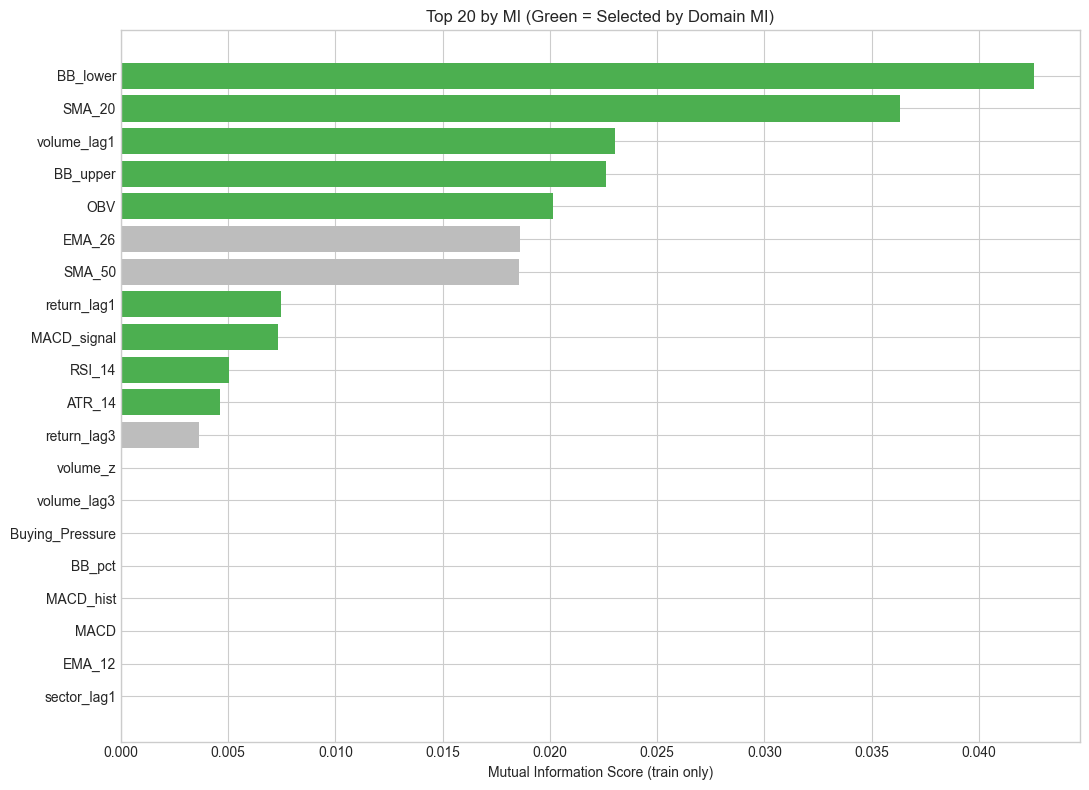

In [136]:
# ── METHOD 1: DOMAIN-BASED MUTUAL INFORMATION (candidate-only, train-only) ────
mi_scores = mutual_info_regression(X_fs_train, y_fs_train, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=X_fs_train.columns).sort_values(ascending=False)

DOMAIN_GROUPS = {
    'MACD':               ['MACD', 'MACD_signal', 'MACD_hist'],
    'Technical_MA':       ['SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26'],
    'Technical_BB':       ['BB_bandwidth', 'BB_pct', 'BB_std'],
    'Price_Action':       ['Buying_Pressure', 'Selling_Pressure'],
    'Volume_Indicators':  ['volume', 'volume_z', 'OBV', 'volume_change'],
    'Return_Lags':        ['return_lag1', 'return_lag2', 'return_lag3', 'return_lag5'],
    'Volume_Lags':        ['volume_lag1', 'volume_lag2', 'volume_lag3', 'volume_lag5'],
    'Sector_Lags':        ['sector_lag1', 'sector_lag2'],
}

features_to_drop_mi = set()
print('METHOD 1: DOMAIN MI')
print('=' * 65)
for domain, kws in DOMAIN_GROUPS.items():
    group = [f for f in X_fs_train.columns if f in kws]
    if len(group) <= 1:
        continue
    winner = mi_series[group].idxmax()
    losers = set(group) - {winner}
    features_to_drop_mi.update(losers)
    print(f'  {domain:<22} → {winner:<24} (MI={mi_series[winner]:.4f}) | -{len(losers)}')

SELECTED_MI = [c for c in X_all.columns if c not in features_to_drop_mi]
print(f'\nMethod 1 → {len(SELECTED_MI)} features selected')

# Plot
fig, ax = plt.subplots(figsize=(11, 8))
top20 = mi_series.head(20)
colors = ['#4CAF50' if f in SELECTED_MI else '#BDBDBD' for f in top20.index]
ax.barh(range(len(top20)), top20.values, color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index)
ax.invert_yaxis()
ax.set_xlabel('Mutual Information Score (train only)')
ax.set_title('Top 20 by MI (Green = Selected by Domain MI)')
plt.tight_layout()
plt.show()

In [137]:
# ── METHOD 1B: DOMAIN-BASED SPEARMAN CORRELATION PRUNING ─────────────────────
# Drops highly redundant features within each domain group using Spearman rank correlation.
# Rule: if |Spearman rho| > 0.95, drop the later feature (keeps the earlier one in the group list).

SPEARMAN_THRESH = 0.95

features_to_drop_spearman = set()

print('METHOD 1B: DOMAIN SPEARMAN PRUNING')
print('=' * 75)

DOMAIN_GROUPS = {
    'Technical_Momentum': ['RSI_14', 'Stoch_K', 'Stoch_D', 'Williams_R',
                           'CCI', 'ROC_10', 'MFI_14'],
    'MACD':               ['MACD', 'MACD_signal', 'MACD_hist'],
    'Technical_MA':       ['SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26'],
    'Technical_BB':       ['BB_bandwidth', 'BB_pct', 'BB_std'],
    'Price_Action':       ['Buying_Pressure', 'Selling_Pressure'],
    'Volume_Indicators':  ['volume', 'volume_z', 'OBV', 'volume_change'],
    'Return_Lags':        ['return_lag1', 'return_lag2', 'return_lag3', 'return_lag5'],
    'Volume_Lags':        ['volume_lag1', 'volume_lag2', 'volume_lag3', 'volume_lag5'],
    'Sector_Lags':        ['sector_lag1', 'sector_lag2']
}

for domain, kws in DOMAIN_GROUPS.items():
    # Keep only features that actually exist in candidate FS train matrix
    group = [f for f in kws if f in X_fs_train.columns]

    if len(group) <= 1:
        continue

    # Spearman correlation within this domain (absolute value for both +ve/-ve monotonic redundancy)
    corr = X_fs_train[group].corr(method='spearman').abs()

    # Upper triangle only (avoid duplicate pairs and diagonal)
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    # Drop any column that has correlation > threshold with an earlier column
    to_drop = [col for col in upper.columns if (upper[col] > SPEARMAN_THRESH).any()]

    features_to_drop_spearman.update(to_drop)

    kept = [f for f in group if f not in to_drop]
    print(f'  {domain:<22} | kept={len(kept):<2} dropped={len(to_drop):<2} | keep: {kept}')
    if to_drop:
        print(f'  {"":<22} | dropped: {to_drop}')

SELECTED_SPEARMAN = [c for c in X_all.columns if c not in features_to_drop_spearman]

print(f'\nMethod 1B → {len(SELECTED_SPEARMAN)} features selected')

METHOD 1B: DOMAIN SPEARMAN PRUNING
  MACD                   | kept=2  dropped=1  | keep: ['MACD', 'MACD_hist']
                         | dropped: ['MACD_signal']
  Technical_MA           | kept=2  dropped=2  | keep: ['SMA_20', 'SMA_50']
                         | dropped: ['EMA_12', 'EMA_26']
  Volume_Indicators      | kept=2  dropped=0  | keep: ['volume_z', 'OBV']
  Return_Lags            | kept=2  dropped=0  | keep: ['return_lag1', 'return_lag3']
  Volume_Lags            | kept=2  dropped=0  | keep: ['volume_lag1', 'volume_lag3']

Method 1B → 17 features selected


METHOD 3: RANDOM FOREST
  16 features capture >= 90% cumulative importance


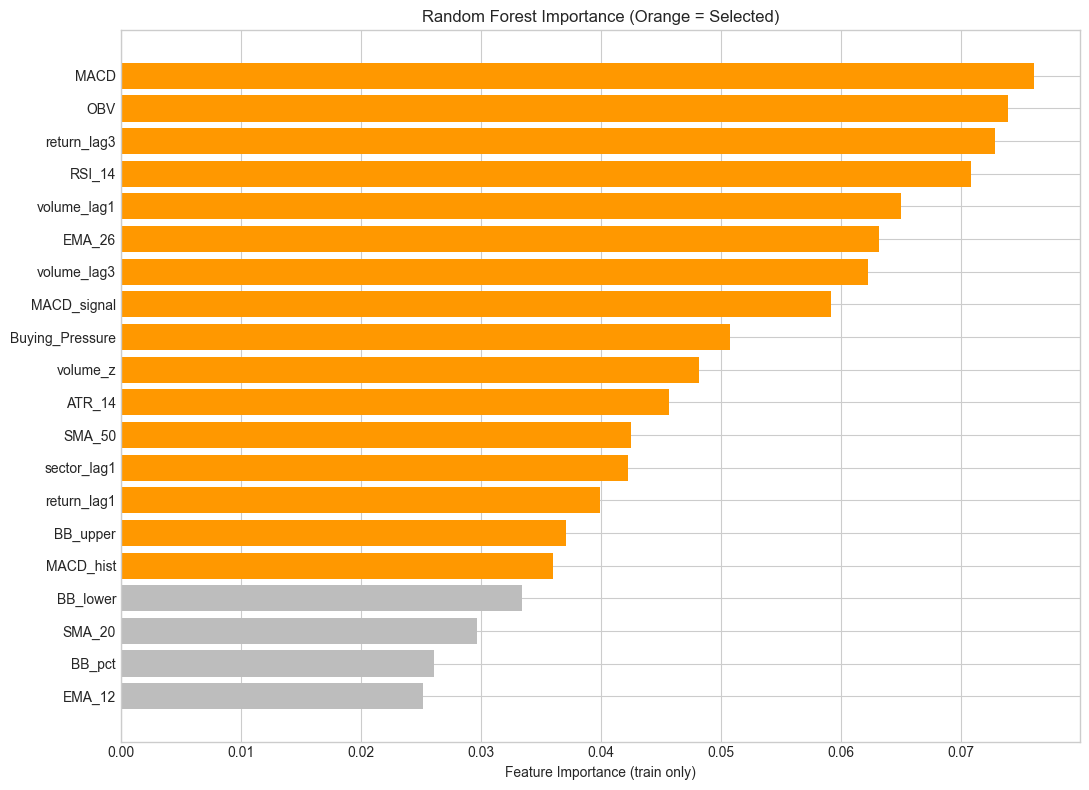

In [138]:
# ── METHOD 3: RANDOM FOREST IMPORTANCE ──────────────────────────
rf_sel = RandomForestRegressor(n_estimators=200, max_depth=6,
                               random_state=RANDOM_STATE, n_jobs=-1)
rf_sel.fit(X_fs_train, y_fs_train)

rf_imp = pd.Series(rf_sel.feature_importances_,
                   index=X_fs_train.columns).sort_values(ascending=False)
cumul = rf_imp.cumsum() / rf_imp.sum()
SELECTED_RF = rf_imp[cumul <= 0.90].index.tolist()
if len(SELECTED_RF) < 10:
    SELECTED_RF = rf_imp.head(min(15, len(rf_imp))).index.tolist()

print(f'METHOD 3: RANDOM FOREST')
print(f'  {len(SELECTED_RF)} features capture >= 90% cumulative importance')

fig, ax = plt.subplots(figsize=(11, 8))
top20 = rf_imp.head(20)
colors = ['#FF9800' if f in SELECTED_RF else '#BDBDBD' for f in top20.index]
ax.barh(range(len(top20)), top20.values, color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (train only)')
ax.set_title('Random Forest Importance (Orange = Selected)')
plt.tight_layout()
plt.show()

METHOD 4: RFE (Ridge, n=10)
  Selected: ['SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'MACD_signal', 'RSI_14', 'BB_upper', 'OBV', 'volume_lag1', 'volume_lag3']


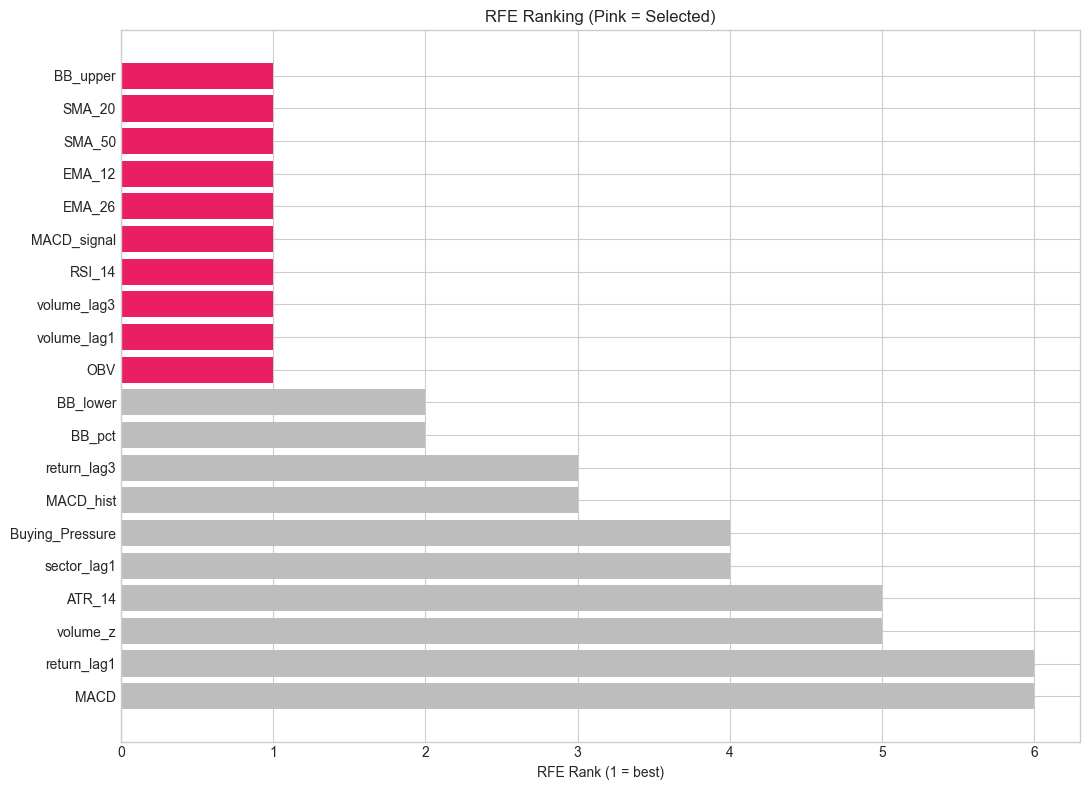

In [139]:
# ── METHOD 4: RFE (Recursive Feature Elimination) ────────────────
ridge_rfe = Ridge(alpha=1.0)

# If candidate pool is small (e.g., 20), selecting all 20 is useless.
# Keep about half (minimum 5).
n_cand = X_fs_train_scaled_df.shape[1]
rfe_n = max(5, min(10, n_cand))   # for 20 candidates -> 10

rfe = RFE(estimator=ridge_rfe, n_features_to_select=rfe_n, step=2)
rfe.fit(X_fs_train_scaled_df, y_fs_train)

SELECTED_RFE = X_fs_train.columns[rfe.support_].tolist()
rfe_ranking = pd.Series(rfe.ranking_, index=X_fs_train.columns).sort_values()

print(f'METHOD 4: RFE (Ridge, n={rfe_n})')
print(f'  Selected: {SELECTED_RFE}')

fig, ax = plt.subplots(figsize=(11, 8))
top25 = rfe_ranking.head(min(25, len(rfe_ranking)))
colors = ['#E91E63' if f in SELECTED_RFE else '#BDBDBD' for f in top25.index]
ax.barh(range(len(top25)), top25.values, color=colors)
ax.set_yticks(range(len(top25)))
ax.set_yticklabels(top25.index)
ax.invert_yaxis()
ax.set_xlabel('RFE Rank (1 = best)')
ax.set_title('RFE Ranking (Pink = Selected)')
plt.tight_layout()
plt.show()

METHOD 5: SHAP — top 10 features
  ['MACD', 'MACD_signal', 'volume_lag3', 'OBV', 'RSI_14', 'return_lag3', 'volume_lag1', 'volume_z', 'SMA_20', 'Buying_Pressure']


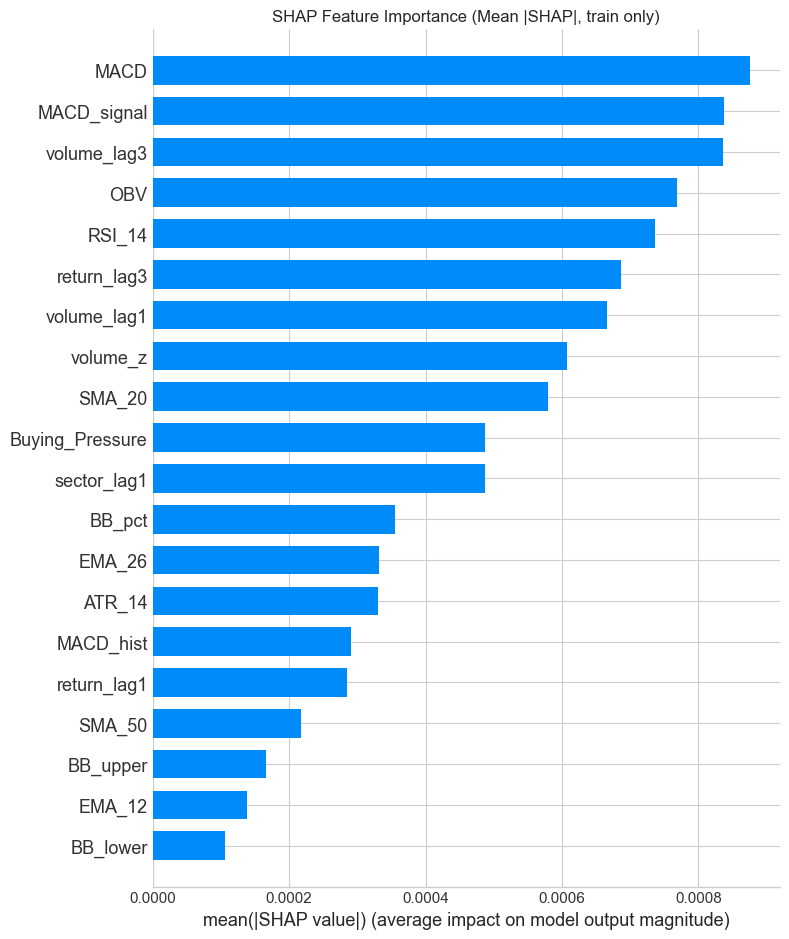

In [140]:
# ── METHOD 5: SHAP ───────────────────────────────────────────────
if SHAP_AVAILABLE:
    lgbm_shap = LGBMRegressor(n_estimators=200, learning_rate=0.05,
                              max_depth=4, random_state=RANDOM_STATE, verbosity=-1)
    lgbm_shap.fit(X_fs_train, y_fs_train)

    explainer = shap.TreeExplainer(lgbm_shap)
    shap_values = explainer.shap_values(X_fs_train)

    shap_mean = pd.Series(np.abs(shap_values).mean(axis=0),
                          index=X_fs_train.columns).sort_values(ascending=False)

    shap_n = max(5, min(10, len(shap_mean)))   # for 20 candidates -> 10
    SELECTED_SHAP = shap_mean.head(shap_n).index.tolist()

    print(f'METHOD 5: SHAP — top {shap_n} features')
    print(f'  {SELECTED_SHAP}')

    shap.summary_plot(shap_values, X_fs_train, plot_type='bar', max_display=min(20, len(shap_mean)), show=False)
    plt.title('SHAP Feature Importance (Mean |SHAP|, train only)')
    plt.tight_layout()
    plt.show()
else:
    print('SHAP not installed. pip install shap')
    SELECTED_SHAP = SELECTED_MI  # fallback

In [141]:
# ── FEATURE SELECTION SUMMARY — MAJORITY VOTE ────────────────────
all_methods = {
    'Domain MI':      set(SELECTED_MI),
    'Random Forest':  set(SELECTED_RF),
    'RFE':            set(SELECTED_RFE),
    'SHAP':           set(SELECTED_SHAP),
    'Spearman':       set(SELECTED_SPEARMAN)
}

vote_df = pd.DataFrame(
    {m: [1 if f in s else 0 for f in X_all.columns] for m, s in all_methods.items()},
    index=X_all.columns
)
vote_df['Total'] = vote_df.sum(axis=1)
vote_df = vote_df.sort_values('Total', ascending=False)

print('VOTES (5 methods):')
print(vote_df.to_string())

SELECTED_BY_MAJORITY = vote_df[vote_df['Total'] >= 3].index.tolist()
print(f'\n>= 3/5 votes: {len(SELECTED_BY_MAJORITY)} candidate features')
print(f'  {SELECTED_BY_MAJORITY}')

# ---------------------------------------------------------------
# Build final model feature set:
#   selected candidate features + always-keep feature columns
# (exclude meta/targets and never-use cols from model X)
# ---------------------------------------------------------------
ALWAYS_KEEP_MODEL_COLS = [
    c for c in (INCLUDED_COLS)
    if c in df_wins.columns
]

# Optional: choose which candidate-selected set to use
#   SELECTED_MI | SELECTED_RF | SELECTED_RFE | SELECTED_SHAP | SELECTED_SPEARMAN | SELECTED_BY_MAJORITY
SELECTED_CANDIDATES = SELECTED_BY_MAJORITY

# Final model features used for training
SELECTED = list(dict.fromkeys(SELECTED_CANDIDATES + ALWAYS_KEEP_MODEL_COLS))

print(f'\nSelected candidate features : {len(SELECTED_CANDIDATES)}')
print(f'Always-keep model features  : {len(ALWAYS_KEEP_MODEL_COLS)}')
print(f'*** Final model feature set : {len(SELECTED)} features ***')

VOTES (5 methods):
                 Domain MI  Random Forest  RFE  SHAP  Spearman  Total
volume_lag1              1              1    1     1         1      5
RSI_14                   1              1    1     1         1      5
OBV                      1              1    1     1         1      5
Buying_Pressure          1              1    0     1         1      4
volume_lag3              0              1    1     1         1      4
MACD_signal              1              1    1     1         0      4
BB_upper                 1              1    1     0         1      4
SMA_20                   1              0    1     1         1      4
ATR_14                   1              1    0     0         1      3
return_lag3              0              1    0     1         1      3
return_lag1              1              1    0     0         1      3
volume_z                 0              1    0     1         1      3
sector_lag1              1              1    0     0         1      3
M

---
## Step 8: Interaction Features & Rolling Standardisation

**Interaction features** capture combined signals:
e.g., `Buying_Pressure × volume_z` = volume spike + bullish price action.

**Rolling standardisation** (30-day backward window, shift(1)):
$$z_t = \dfrac{x_t - \mu(x_{t-30:t-1})}{\sigma(x_{t-30:t-1})}$$
Ensures normalisation uses only past data — no future leakage.


In [142]:
# ── Interaction features (top 6 by MI on SELECTED_CANDIDATES) ──────────────
# Use only selected candidate features for interactions (not macro/fundamental/meta/targets)
mi_sel = mutual_info_regression(df_wins[SELECTED_CANDIDATES].fillna(0), y_res,
                                random_state=RANDOM_STATE)
top_6 = pd.Series(mi_sel, index=SELECTED_CANDIDATES).nlargest(min(6, len(SELECTED_CANDIDATES))).index.tolist()
print(f'Interactions from top-6 candidate features: {top_6}')

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
inter_arr = poly.fit_transform(df_wins[top_6])
inter_names = poly.get_feature_names_out(top_6)

# Keep only interaction terms (drop original columns from poly output)
interaction_names = [n for n in inter_names if ' ' in n]
interaction_idx = [i for i, n in enumerate(inter_names) if ' ' in n]
inter_df = pd.DataFrame(inter_arr[:, interaction_idx], columns=interaction_names, index=df_wins.index)

df_final = pd.concat([df_wins, inter_df], axis=1)
ALL_FEATS = list(dict.fromkeys(SELECTED + interaction_names))

print(f'Added {len(interaction_names)} interaction features')
print(f'Total features: {len(ALL_FEATS)}')

# ── Rolling standardisation ───────────────────────────────────────
ROLLING_WINDOW = 30
df_scaled = df_final.copy()

# Don't standardise these
NO_SCALE_COLS = set(META_COLS + TARGET_COLS + FUNDAMENTAL_COLS)

for col in ALL_FEATS:
    if col not in df_final.columns or col in NO_SCALE_COLS:
        continue
    rm = df_final[col].shift(1).rolling(ROLLING_WINDOW, min_periods=10).mean()
    rs = df_final[col].shift(1).rolling(ROLLING_WINDOW, min_periods=10).std()
    df_scaled[col] = (df_final[col] - rm) / rs.replace(0, np.nan)

# Remove duplicate columns first
df_scaled = df_scaled.loc[:, ~df_scaled.columns.duplicated()].copy()

# Replace inf from scaling
feat_cols_present = [c for c in ALL_FEATS if c in df_scaled.columns]
df_scaled[feat_cols_present] = df_scaled[feat_cols_present].replace([np.inf, -np.inf], np.nan)

# IMPORTANT: do NOT drop rows based on all features (this was shrinking data too much)
# Fill feature NaNs (created by rolling warm-up / zero std / interactions)
df_scaled[feat_cols_present] = df_scaled[feat_cols_present].ffill().fillna(0)

# Only target rows must be present
df_scaled = df_scaled.dropna(subset=['target_residualized', 'target_raw_return']).copy()

print(f'Rolling standardisation done. Final rows: {len(df_scaled)}')

Interactions from top-6 candidate features: ['OBV', 'SMA_20', 'ATR_14', 'BB_upper', 'SMA_50', 'volume_lag3']
Added 15 interaction features
Total features: 60
Rolling standardisation done. Final rows: 1420


---
## Step 9: Train / Validation / Test Split

**Chronological — never random for time-series data!**
```
├── Train (70%) ── Learn patterns from historical data
├── Val   (15%) ── Hyperparameter tuning / early stopping
└── Test  (15%) ── Final evaluation (unseen data)
```


In [143]:
print("Initial df rows:", len(df))
print("Initial date range:", df['date'].min(), "to", df['date'].max())

# check missingness of candidate features
cand_nan = df[candidate_features].isnull().mean().sort_values(ascending=False) * 100
print("\nTop 20 candidate features by %NaN:")
print(cand_nan.head(20))

# how many rows survive if only targets are required?
tmp_targets = ['target_residualized', 'target_raw_return']
tmp_targets = [c for c in tmp_targets if c in df.columns]
print("\nRows after dropping NaN on targets only:",
      len(df.replace([np.inf, -np.inf], np.nan).dropna(subset=tmp_targets)))

# how many rows survive with current required_cols?
required_cols = [c for c in (candidate_features + tmp_targets) if c in df.columns]
print("No. of required cols in current dropna:", len(required_cols))
print("Rows after dropping NaN on ALL candidate+targets:",
      len(df.replace([np.inf, -np.inf], np.nan).dropna(subset=required_cols)))

# see which columns are killing rows the most (approx)
row_na_count = df[required_cols].isnull().sum().sort_values(ascending=False)
print("\nTop 20 row-killer cols (#NaN):")
print(row_na_count.head(20))

Initial df rows: 1486
Initial date range: 2020-01-01 00:00:00 to 2025-12-30 00:00:00

Top 20 candidate features by %NaN:
SMA_50             3.297443
BB_lower           1.278600
volume_z           1.278600
BB_upper           1.278600
SMA_20             1.278600
BB_pct             1.278600
RSI_14             0.874832
ATR_14             0.874832
volume_lag3        0.201884
return_lag3        0.201884
OBV                0.067295
volume_lag1        0.067295
return_lag1        0.067295
sector_lag1        0.067295
MACD_hist          0.000000
MACD_signal        0.000000
MACD               0.000000
EMA_26             0.000000
EMA_12             0.000000
Buying_Pressure    0.000000
dtype: float64

Rows after dropping NaN on targets only: 1469
No. of required cols in current dropna: 22
Rows after dropping NaN on ALL candidate+targets: 1420

Top 20 row-killer cols (#NaN):
SMA_50                 49
BB_pct                 19
volume_z               19
BB_upper               19
BB_lower               

In [144]:
n         = len(df_scaled)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

# Safety: ensure model X never includes meta/target/leaky/redundant cols
forbidden_for_X = set(META_COLS + TARGET_COLS + LEAKY_COLS + REDUNDANT_COLS)
available_feats = [c for c in ALL_FEATS if c in df_scaled.columns and c not in forbidden_for_X]

X          = df_scaled[available_feats]
y_raw_full = df_scaled['target_raw_return']
y_res_full = df_scaled['target_residualized']
y_binary   = (y_res_full >= 0).astype(int)

X_train, y_train_raw, y_train_res = X.iloc[:train_end],       y_raw_full.iloc[:train_end],       y_res_full.iloc[:train_end]
X_val,   y_val_raw,   y_val_res   = X.iloc[train_end:val_end], y_raw_full.iloc[train_end:val_end], y_res_full.iloc[train_end:val_end]
X_test,  y_test_raw,  y_test_res  = X.iloc[val_end:],         y_raw_full.iloc[val_end:],         y_res_full.iloc[val_end:]

y_train_bin = y_binary.iloc[:train_end]
y_val_bin   = y_binary.iloc[train_end:val_end]
y_test_bin  = y_binary.iloc[val_end:]
dates_test  = df_scaled['date'].iloc[val_end:]
ALL_FEATS   = available_feats  # sync with available cols

print(f'Train : {len(X_train):5d} rows  ({df_scaled["date"].iloc[0].date()} → {df_scaled["date"].iloc[train_end-1].date()})')
print(f'Val   : {len(X_val):5d} rows')
if len(X_test) > 0:
    print(f'Test  : {len(X_test):5d} rows  ({dates_test.iloc[0].date()} → {dates_test.iloc[-1].date()})')
else:
    print(f'Test  : {len(X_test):5d} rows')

print()
print(f'Features used for model: {len(ALL_FEATS)}')
print(f'Class balance (train): Up={y_train_bin.sum()} ({y_train_bin.mean()*100:.1f}%)  Down={(~y_train_bin.astype(bool)).sum()}')
print(f'Class balance (test) : Up={y_test_bin.sum()}  ({y_test_bin.mean()*100:.1f}%)  Down={(~y_test_bin.astype(bool)).sum()}')

Train :   993 rows  (2020-03-12 → 2024-04-04)
Val   :   214 rows
Test  :   213 rows  (2025-02-17 → 2025-12-29)

Features used for model: 54
Class balance (train): Up=472 (47.5%)  Down=521
Class balance (test) : Up=109  (51.2%)  Down=104


In [145]:
df.head()

,date,open,high,low,close,volume,stock_log_return,volume_change,eps,pe_ratio,revenue,revenue_growth,net_income,profit_margin,profit_growth,nifty50_return,sector_return,india_vix,repo_rate,tbill_91d,gsec_10y_yield,yield_curve_spread,cpi,cg_securities_cr,sg_securities_cr,fii_net_cr,dii_net_cr,usd_inr,gbp_inr,eur_inr,jpy_inr,crude_brent_return,gold_return,sentiment_score,target_raw_return,target_residualized,Buying_Pressure,Selling_Pressure,SMA_20,SMA_50,EMA_12,EMA_26,MACD,MACD_signal,MACD_hist,RSI_14,BB_mid,BB_upper,BB_lower,BB_pct,ATR_14,OBV,volume_z,return_lag1,volume_lag1,return_lag3,volume_lag3,sector_lag1
0,2020-01-01,679.081936,683.152852,673.490062,675.324158,14004468,0.016881,0.234771,9.12,74.048702,1533020.0,2.4,116400.0,7.6,-0.9,0.008151,0.008762,11.49,5.15,4.9386,6.729,1.7904,150.2,322171.854,26014.77,-5359.5,1073.5,71.3717,94.6413,80.0305,65.69,0.034857,0.016072,0.0,0.016881,0.008119,0.189810,0.810190,NaN,NaN,675.324158,675.324158,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-02,676.397899,689.348791,676.397899,686.821228,17710316,0.016881,0.234771,9.12,75.309345,1533020.0,2.4,116400.0,7.6,-0.9,0.008151,0.008762,11.49,5.15,4.9386,6.729,1.7904,150.2,322171.854,26014.77,-5359.5,1073.5,71.3429,94.2535,79.9392,65.61,0.034857,0.016072,0.0,0.001204,0.005784,0.804835,0.195165,NaN,NaN,677.092938,676.175793,0.917145,0.183429,0.733716,NaN,NaN,NaN,NaN,NaN,NaN,17710316.0,NaN,0.016881,14004468.0,NaN,NaN,0.008762
2,2020-01-03,685.792313,689.661956,681.318790,687.648865,20984698,0.001204,0.169646,9.12,75.400095,1533020.0,2.4,116400.0,7.6,-0.9,-0.004533,-0.004580,12.70,5.15,4.9386,6.729,1.7904,150.2,322171.854,26014.77,-5359.5,1073.5,71.6949,93.9891,80.0507,66.32,0.034857,0.016072,0.0,-0.023466,-0.003476,0.758714,0.241286,NaN,NaN,678.716927,677.025650,1.691277,0.484999,1.206278,NaN,NaN,NaN,NaN,NaN,NaN,38695014.0,NaN,0.016881,17710316.0,NaN,NaN,0.008762
3,2020-01-06,679.976657,683.510705,670.134872,671.700623,24519177,-0.023466,0.155662,9.12,73.651384,1533020.0,2.4,116400.0,7.6,-0.9,-0.019291,-0.019990,14.78,5.15,4.9386,6.729,1.7904,150.2,322171.854,26014.77,-5359.5,1073.5,72.0919,94.2890,80.4531,66.74,0.004509,0.010914,0.0,0.015268,0.011671,0.117058,0.882942,NaN,NaN,677.637495,676.631203,1.006292,0.589257,0.417035,NaN,NaN,NaN,NaN,NaN,NaN,14175837.0,NaN,0.001204,20984698.0,0.016881,14004468.0,-0.004580
4,2020-01-07,679.529321,686.463335,677.068889,682.034546,16683622,0.015268,-0.385028,9.12,74.784490,1533020.0,2.4,116400.0,7.6,-0.9,0.004982,0.003596,14.61,5.15,4.9386,6.729,1.7904,150.2,322171.854,26014.77,-5359.5,1073.5,71.7764,94.4300,80.2805,66.22,-0.009331,0.003569,0.0,-0.007538,0.000650,0.528574,0.471426,NaN,NaN,678.313964,677.031451,1.282514,0.727909,0.554605,NaN,NaN,NaN,NaN,NaN,NaN,30859459.0,NaN,-0.023466,24519177.0,0.016881,17710316.0,-0.019990


---
## Step 10: Model Training

| # | Model | Task | Target |
|:--|:---|:---|:---|
| 1 | LightGBM Regressor | Regression | target_raw_return |
| 2 | LightGBM Classifier | Classification | target_residualized dir. |
| 3 | XGBoost Regressor | Regression | target_raw_return |
| 4 | XGBoost Classifier | Classification | target_residualized dir. |
| 5 | Random Forest Regressor | Regression | target_raw_return |
| 6 | Random Forest Classifier | Classification | target_residualized dir. |
| 7 | CatBoost  | Regression | target_raw_return |


In [146]:
# ============================================================
# Model Training and Hyperparameter Tuning
# ============================================================

import numpy as np
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, log_loss
)

# ---------------------------
# Final test evaluation helpers
# ---------------------------
results = {}
best_params_all = {}
best_val_scores = {}

def eval_reg(model, Xt, yt, name):
    p    = model.predict(Xt)
    r2   = r2_score(yt, p)
    mae  = mean_absolute_error(yt, p)
    rmse = np.sqrt(mean_squared_error(yt, p))
    da   = (np.sign(p) == np.sign(yt)).mean()
    return {'pred': p, 'r2': r2, 'mae': mae, 'rmse': rmse, 'dir_acc': da}

def eval_clf(model, Xt, yb, name):
    pb   = model.predict(Xt)
    pp   = model.predict_proba(Xt)[:, 1]
    acc  = accuracy_score(yb, pb)
    conf = np.abs(pp - 0.5)
    thr  = np.percentile(conf, 80)
    hcm  = conf >= thr
    acc_hc = accuracy_score(yb[hcm], pb[hcm]) if hcm.sum() > 0 else 0
    return {'pred_bin': pb, 'pred_prob': pp, 'acc': acc, 'acc_hc': acc_hc, 'hc_mask': hcm}

# ---------------------------
# Validation scoring helpers
# ---------------------------
def reg_val_metrics(model, Xv, yv):
    p = model.predict(Xv)
    return {
        'val_r2': r2_score(yv, p),
        'val_mae': mean_absolute_error(yv, p),
        'val_rmse': np.sqrt(mean_squared_error(yv, p)),
        'val_dir_acc': (np.sign(p) == np.sign(yv)).mean()
    }

def clf_val_metrics(model, Xv, yv):
    pb = model.predict(Xv)
    pp = model.predict_proba(Xv)[:, 1]
    pp = np.clip(pp, 1e-6, 1 - 1e-6)  # avoid log-loss inf
    return {
        'val_acc': accuracy_score(yv, pb),
        'val_logloss': log_loss(yv, pp)
    }

# ---------------------------
# Generic tuning loops
# ---------------------------
def tune_regressor(model_name, build_model_fn, param_grid, fit_fn):
    combos = list(ParameterGrid(param_grid))
    print(f"\n{'='*100}")
    print(f"TUNING REGRESSOR: {model_name} | total combinations = {len(combos)}")
    print(f"Selection metric: MIN validation RMSE")
    print(f"{'='*100}")

    best_model = None
    best_params = None
    best_metrics = None
    best_score = np.inf

    for i, params in enumerate(combos, 1):
        print(f"[{model_name}] Trial {i}/{len(combos)} | params = {params}")
        try:
            model = build_model_fn(params)
            fit_fn(model)
            vm = reg_val_metrics(model, X_val, y_val_raw)

            print(f"    -> Val RMSE: {vm['val_rmse']:.6f} | Val MAE: {vm['val_mae']:.6f} | "
                  f"Val R²: {vm['val_r2']:.4f} | Val DirAcc: {vm['val_dir_acc']*100:.2f}%")

            if vm['val_rmse'] < best_score:
                best_score = vm['val_rmse']
                best_model = model
                best_params = params
                best_metrics = vm
                print(f"    ✅ New BEST for {model_name} (Val RMSE = {best_score:.6f})")
            else:
                print(f"    .. no improvement (current best RMSE = {best_score:.6f})")

        except Exception as e:
            print(f"    ❌ Trial failed for {model_name} with params={params}")
            print(f"       Error: {e}")

    print(f"\n[{model_name}] Best params: {best_params}")
    if best_metrics is not None:
        print(f"[{model_name}] Best validation metrics: {best_metrics}")

    return best_model, best_params, best_metrics

def tune_classifier(model_name, build_model_fn, param_grid, fit_fn):
    combos = list(ParameterGrid(param_grid))
    print(f"\n{'='*100}")
    print(f"TUNING CLASSIFIER: {model_name} | total combinations = {len(combos)}")
    print(f"Selection metric: MIN validation LogLoss (tie-breaker: MAX validation Accuracy)")
    print(f"{'='*100}")

    best_model = None
    best_params = None
    best_metrics = None
    best_logloss = np.inf
    best_acc = -np.inf

    for i, params in enumerate(combos, 1):
        print(f"[{model_name}] Trial {i}/{len(combos)} | params = {params}")
        try:
            model = build_model_fn(params)
            fit_fn(model)
            vm = clf_val_metrics(model, X_val, y_val_bin)

            print(f"    -> Val LogLoss: {vm['val_logloss']:.6f} | Val Acc: {vm['val_acc']*100:.2f}%")

            improved = (
                vm['val_logloss'] < best_logloss - 1e-12 or
                (abs(vm['val_logloss'] - best_logloss) <= 1e-12 and vm['val_acc'] > best_acc)
            )
            if improved:
                best_logloss = vm['val_logloss']
                best_acc = vm['val_acc']
                best_model = model
                best_params = params
                best_metrics = vm
                print(f"    ✅ New BEST for {model_name} (Val LogLoss = {best_logloss:.6f}, "
                      f"Val Acc = {best_acc*100:.2f}%)")
            else:
                print(f"    .. no improvement (best LogLoss = {best_logloss:.6f}, "
                      f"best Acc = {best_acc*100:.2f}%)")

        except Exception as e:
            print(f"    ❌ Trial failed for {model_name} with params={params}")
            print(f"       Error: {e}")

    print(f"\n[{model_name}] Best params: {best_params}")
    if best_metrics is not None:
        print(f"[{model_name}] Best validation metrics: {best_metrics}")

    return best_model, best_params, best_metrics

# ---------------------------
# Hyperparameter grids (selected models only)
# ---------------------------
grids = {
    'LGBM_Reg': {
        'learning_rate': [0.03, 0.05],
        'max_depth': [3, 5],
        'num_leaves': [15, 31],
        'min_child_samples': [20, 50]
    },
    'LGBM_Clf': {
        'learning_rate': [0.03, 0.05],
        'max_depth': [3, 5],
        'num_leaves': [15, 31],
        'min_child_samples': [20, 50]
    },
    'XGB_Reg': {
        'learning_rate': [0.03, 0.05],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    },
    'XGB_Clf': {
        'learning_rate': [0.03, 0.05],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    },
    'RF_Reg': {
        'n_estimators': [200, 400],
        'max_depth': [5, 7, None],
        'min_samples_leaf': [1, 3]
    },
    'RF_Clf': {
        'n_estimators': [200, 400],
        'max_depth': [5, 7, None],
        'min_samples_leaf': [1, 3]
    }
}

if CATBOOST_AVAILABLE:
    grids['CatBoost'] = {
        'depth': [4, 6, 8],
        'learning_rate': [0.03, 0.05],
        'l2_leaf_reg': [3, 5, 7]
    }

# ---------------------------
# Model tuning + fitting
# ---------------------------

total_models = 7 if CATBOOST_AVAILABLE else 6

# 1) LightGBM Regressor
print(f'\n1/{total_models}  LightGBM Regressor (tuning)...')
m_lgbm_reg, p_lgbm_reg, v_lgbm_reg = tune_regressor(
    'LGBM_Reg',
    build_model_fn=lambda p: LGBMRegressor(
        n_estimators=1000,
        learning_rate=p['learning_rate'],
        max_depth=p['max_depth'],
        num_leaves=p['num_leaves'],
        min_child_samples=p['min_child_samples'],
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    ),
    param_grid=grids['LGBM_Reg'],
    fit_fn=lambda model: model.fit(
        X_train, y_train_raw,
        eval_set=[(X_val, y_val_raw)],
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )
)
best_params_all['LGBM_Reg'] = p_lgbm_reg
best_val_scores['LGBM_Reg'] = v_lgbm_reg
results['LGBM_Reg'] = eval_reg(m_lgbm_reg, X_test, y_test_raw, 'LGBM_Reg')

# 2) LightGBM Classifier
print(f'\n2/{total_models}  LightGBM Classifier (tuning)...')
m_lgbm_clf, p_lgbm_clf, v_lgbm_clf = tune_classifier(
    'LGBM_Clf',
    build_model_fn=lambda p: LGBMClassifier(
        n_estimators=1000,
        learning_rate=p['learning_rate'],
        max_depth=p['max_depth'],
        num_leaves=p['num_leaves'],
        min_child_samples=p['min_child_samples'],
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    ),
    param_grid=grids['LGBM_Clf'],
    fit_fn=lambda model: model.fit(
        X_train, y_train_bin,
        eval_set=[(X_val, y_val_bin)],
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )
)
best_params_all['LGBM_Clf'] = p_lgbm_clf
best_val_scores['LGBM_Clf'] = v_lgbm_clf
results['LGBM_Clf'] = eval_clf(m_lgbm_clf, X_test, y_test_bin, 'LGBM_Clf')

# 3) XGBoost Regressor
print(f'\n3/{total_models}  XGBoost Regressor (tuning)...')
m_xgb_reg, p_xgb_reg, v_xgb_reg = tune_regressor(
    'XGB_Reg',
    build_model_fn=lambda p: XGBRegressor(
        n_estimators=1000,
        learning_rate=p['learning_rate'],
        max_depth=p['max_depth'],
        subsample=p['subsample'],
        colsample_bytree=p['colsample_bytree'],
        random_state=RANDOM_STATE,
        n_jobs=-1,
        early_stopping_rounds=30,
        eval_metric='rmse',
        verbosity=0
    ),
    param_grid=grids['XGB_Reg'],
    fit_fn=lambda model: model.fit(
        X_train, y_train_raw,
        eval_set=[(X_val, y_val_raw)],
        verbose=False
    )
)
best_params_all['XGB_Reg'] = p_xgb_reg
best_val_scores['XGB_Reg'] = v_xgb_reg
results['XGB_Reg'] = eval_reg(m_xgb_reg, X_test, y_test_raw, 'XGB_Reg')

# 4) XGBoost Classifier
print(f'\n4/{total_models}  XGBoost Classifier (tuning)...')
m_xgb_clf, p_xgb_clf, v_xgb_clf = tune_classifier(
    'XGB_Clf',
    build_model_fn=lambda p: XGBClassifier(
        n_estimators=1000,
        learning_rate=p['learning_rate'],
        max_depth=p['max_depth'],
        subsample=p['subsample'],
        colsample_bytree=p['colsample_bytree'],
        random_state=RANDOM_STATE,
        n_jobs=-1,
        early_stopping_rounds=30,
        eval_metric='logloss',
        verbosity=0
    ),
    param_grid=grids['XGB_Clf'],
    fit_fn=lambda model: model.fit(
        X_train, y_train_bin,
        eval_set=[(X_val, y_val_bin)],
        verbose=False
    )
)
best_params_all['XGB_Clf'] = p_xgb_clf
best_val_scores['XGB_Clf'] = v_xgb_clf
results['XGB_Clf'] = eval_clf(m_xgb_clf, X_test, y_test_bin, 'XGB_Clf')

# 5) Random Forest Regressor
print(f'\n5/{total_models}  Random Forest Regressor (tuning)...')
m_rf_reg, p_rf_reg, v_rf_reg = tune_regressor(
    'RF_Reg',
    build_model_fn=lambda p: RandomForestRegressor(
        n_estimators=p['n_estimators'],
        max_depth=p['max_depth'],
        min_samples_leaf=p['min_samples_leaf'],
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_grid=grids['RF_Reg'],
    fit_fn=lambda model: model.fit(X_train, y_train_raw)
)
best_params_all['RF_Reg'] = p_rf_reg
best_val_scores['RF_Reg'] = v_rf_reg
results['RF_Reg'] = eval_reg(m_rf_reg, X_test, y_test_raw, 'RF_Reg')

# 6) Random Forest Classifier
print(f'\n6/{total_models}  Random Forest Classifier (tuning)...')
m_rf_clf, p_rf_clf, v_rf_clf = tune_classifier(
    'RF_Clf',
    build_model_fn=lambda p: RandomForestClassifier(
        n_estimators=p['n_estimators'],
        max_depth=p['max_depth'],
        min_samples_leaf=p['min_samples_leaf'],
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_grid=grids['RF_Clf'],
    fit_fn=lambda model: model.fit(X_train, y_train_bin)
)
best_params_all['RF_Clf'] = p_rf_clf
best_val_scores['RF_Clf'] = v_rf_clf
results['RF_Clf'] = eval_clf(m_rf_clf, X_test, y_test_bin, 'RF_Clf')

# 7) CatBoost Regressor (optional)
if CATBOOST_AVAILABLE:
    print(f'\n7/{total_models}  CatBoost Regressor (tuning)...')
    m_cat, p_cat, v_cat = tune_regressor(
        'CatBoost',
        build_model_fn=lambda p: CatBoostRegressor(
            iterations=1000,
            learning_rate=p['learning_rate'],
            depth=p['depth'],
            l2_leaf_reg=p['l2_leaf_reg'],
            random_seed=RANDOM_STATE,
            verbose=0
        ),
        param_grid=grids['CatBoost'],
        fit_fn=lambda model: model.fit(
            X_train, y_train_raw,
            eval_set=(X_val, y_val_raw),
            early_stopping_rounds=30,
            verbose=False
        )
    )
    best_params_all['CatBoost'] = p_cat
    best_val_scores['CatBoost'] = v_cat
    results['CatBoost'] = eval_reg(m_cat, X_test, y_test_raw, 'CatBoost')
else:
    print('\nCatBoost not available -> skipped.')

# ---------------------------
# Summary
# ---------------------------
print("\n" + "="*110)
print("TUNING COMPLETE — BEST PARAMS / BEST VALIDATION SCORES")
print("="*110)
for k in best_params_all:
    print(f"{k}:")
    print(f"  best_params = {best_params_all[k]}")
    print(f"  best_val    = {best_val_scores[k]}")
print("="*110)

print('\nAll tuned selected models trained and test-evaluated!')


1/7  LightGBM Regressor (tuning)...

TUNING REGRESSOR: LGBM_Reg | total combinations = 16
Selection metric: MIN validation RMSE
[LGBM_Reg] Trial 1/16 | params = {'learning_rate': 0.03, 'max_depth': 3, 'min_child_samples': 20, 'num_leaves': 15}
    -> Val RMSE: 0.014248 | Val MAE: 0.010358 | Val R²: -0.0221 | Val DirAcc: 50.93%
    ✅ New BEST for LGBM_Reg (Val RMSE = 0.014248)
[LGBM_Reg] Trial 2/16 | params = {'learning_rate': 0.03, 'max_depth': 3, 'min_child_samples': 20, 'num_leaves': 31}
    -> Val RMSE: 0.014248 | Val MAE: 0.010358 | Val R²: -0.0221 | Val DirAcc: 50.93%
    .. no improvement (current best RMSE = 0.014248)
[LGBM_Reg] Trial 3/16 | params = {'learning_rate': 0.03, 'max_depth': 3, 'min_child_samples': 50, 'num_leaves': 15}
    -> Val RMSE: 0.014232 | Val MAE: 0.010346 | Val R²: -0.0198 | Val DirAcc: 50.93%
    ✅ New BEST for LGBM_Reg (Val RMSE = 0.014232)
[LGBM_Reg] Trial 4/16 | params = {'learning_rate': 0.03, 'max_depth': 3, 'min_child_samples': 50, 'num_leaves': 31}

---
## Step 11: Results & Evaluation

**Metrics:**
- **R²** — variance explained; >0 beats mean baseline
- **Direction Accuracy** — % correct up/down calls
- **Classifier Accuracy** — direct binary accuracy
- **High-Confidence Accuracy** — accuracy when model confidence > 80th percentile


In [147]:
# =========================
# RESULT TABLES (Train / Val / Test for selected models only)
# =========================

import numpy as np
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, accuracy_score
)

# sklearn version compatibility for RMSE
try:
    from sklearn.metrics import root_mean_squared_error
    def rmse_fn(y_true, y_pred):
        return root_mean_squared_error(y_true, y_pred)
except ImportError:
    def rmse_fn(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

# ---- Keep only strong regressors ----
REG_MODELS = ['LGBM_Reg', 'XGB_Reg', 'RF_Reg']
CLF_MODELS = ['LGBM_Clf', 'XGB_Clf', 'RF_Clf']

if CATBOOST_AVAILABLE and 'CatBoost' in results:
    REG_MODELS.append('CatBoost')

# Explicit model object map (only models you are using)
MODEL_OBJS = {
    'LGBM_Reg': globals().get('m_lgbm_reg', None),
    'LGBM_Clf': globals().get('m_lgbm_clf', None),
    'XGB_Reg':  globals().get('m_xgb_reg', None),
    'XGB_Clf':  globals().get('m_xgb_clf', None),
    'RF_Reg':   globals().get('m_rf_reg', None),
    'RF_Clf':   globals().get('m_rf_clf', None),
    'CatBoost': globals().get('m_cat', None),
}

FILLNA0_REG_MODELS = set()

def _prep_X_for_model(X, model_name):
    """Match preprocessing used during training/evaluation."""
    if model_name in FILLNA0_REG_MODELS:
        return X.fillna(0)
    return X

# -------- Split metric helpers --------
def reg_metrics_on_split(model, model_name, Xs, ys):
    Xs_use = _prep_X_for_model(Xs, model_name)
    pred = model.predict(Xs_use)
    return {
        'r2': r2_score(ys, pred),
        'mae': mean_absolute_error(ys, pred),
        'rmse': rmse_fn(ys, pred),
        'dir_acc': (np.sign(pred) == np.sign(ys)).mean(),
    }

def clf_metrics_on_split(model, Xs, yb):
    pred_bin = model.predict(Xs)
    pred_prob = model.predict_proba(Xs)[:, 1]
    acc = accuracy_score(yb, pred_bin)

    conf = np.abs(pred_prob - 0.5)
    thr = np.percentile(conf, 80)
    hc_mask = conf >= thr
    hc_trades = int(hc_mask.sum())
    acc_hc = accuracy_score(yb[hc_mask], pred_bin[hc_mask]) if hc_trades > 0 else np.nan

    return {
        'acc': acc,
        'acc_hc': acc_hc,
        'hc_trades': hc_trades,
    }

# -------- REGRESSOR TABLE 1: Error Metrics --------
print('REGRESSOR RESULTS — ERROR METRICS (Train / Val / Test)')
print('=' * 130)
print(f'  {"Model":<14} {"Train MAE":>10} {"Val MAE":>10} {"Test MAE":>10}  '
      f'{"Train RMSE":>11} {"Val RMSE":>10} {"Test RMSE":>11}')
print('-' * 130)

for m in REG_MODELS:
    if m not in results:
        continue

    model_obj = MODEL_OBJS.get(m, None)

    # Test metrics from results dict
    r_test = results[m]
    test_mae = r_test.get('mae', np.nan)
    test_rmse = r_test.get('rmse', np.nan)

    if model_obj is not None:
        train_m = reg_metrics_on_split(model_obj, m, X_train, y_train_raw)
        val_m   = reg_metrics_on_split(model_obj, m, X_val,   y_val_raw)
    else:
        train_m = {'mae': np.nan, 'rmse': np.nan}
        val_m   = {'mae': np.nan, 'rmse': np.nan}

    print(f'  {m:<14} {train_m["mae"]:>10.5f} {val_m["mae"]:>10.5f} {test_mae:>10.5f}  '
          f'{train_m["rmse"]:>11.5f} {val_m["rmse"]:>10.5f} {test_rmse:>11.5f}')

print()

# -------- REGRESSOR TABLE 2: Fit + Direction Metrics --------
print('REGRESSOR RESULTS — FIT / DIRECTION METRICS (Train / Val / Test)')
print('=' * 130)
print(f'  {"Model":<14} {"Train R²":>9} {"Val R²":>9} {"Test R²":>9}  '
      f'{"Train DA":>10} {"Val DA":>9} {"Test DA":>10}')
print('-' * 130)

for m in REG_MODELS:
    if m not in results:
        continue

    model_obj = MODEL_OBJS.get(m, None)

    # Test metrics from results dict
    r_test = results[m]
    test_r2 = r_test.get('r2', np.nan)
    test_da = r_test.get('dir_acc', np.nan)

    if model_obj is not None:
        train_m = reg_metrics_on_split(model_obj, m, X_train, y_train_raw)
        val_m   = reg_metrics_on_split(model_obj, m, X_val,   y_val_raw)
    else:
        train_m = {'r2': np.nan, 'dir_acc': np.nan}
        val_m   = {'r2': np.nan, 'dir_acc': np.nan}

    print(f'  {m:<14} {train_m["r2"]:>9.4f} {val_m["r2"]:>9.4f} {test_r2:>9.4f}  '
          f'{train_m["dir_acc"]*100:>9.1f}% {val_m["dir_acc"]*100:>8.1f}% {test_da*100:>9.1f}%')

print()

# -------- CLASSIFIER TABLE: Accuracy + HC Metrics --------
print('CLASSIFIER RESULTS (target_residualized direction) — Train / Val / Test')
print('=' * 150)
print(f'  {"Model":<14} '
      f'{"Train Acc":>10} {"Val Acc":>9} {"Test Acc":>10}  '
      f'{"Train HC Acc":>13} {"Val HC Acc":>11} {"Test HC Acc":>12}  '
      f'{"Train HC":>10} {"Val HC":>8} {"Test HC":>9}')
print('-' * 150)

for m in CLF_MODELS:
    if m not in results:
        continue

    model_obj = MODEL_OBJS.get(m, None)

    # Test metrics from results dict
    r_test = results[m]
    test_acc = r_test.get('acc', np.nan)
    test_acc_hc = r_test.get('acc_hc', np.nan)
    test_hc_trades = int(r_test['hc_mask'].sum()) if 'hc_mask' in r_test else 0

    if model_obj is not None:
        train_m = clf_metrics_on_split(model_obj, X_train, y_train_bin)
        val_m   = clf_metrics_on_split(model_obj, X_val,   y_val_bin)
    else:
        train_m = {'acc': np.nan, 'acc_hc': np.nan, 'hc_trades': 0}
        val_m   = {'acc': np.nan, 'acc_hc': np.nan, 'hc_trades': 0}

    print(
        f'  {m:<14} '
        f'{train_m["acc"]*100:>9.1f}% {val_m["acc"]*100:>8.1f}% {test_acc*100:>9.1f}%  '
        f'{train_m["acc_hc"]*100:>12.1f}% {val_m["acc_hc"]*100:>10.1f}% {test_acc_hc*100:>11.1f}%  '
        f'{train_m["hc_trades"]:>10d} {val_m["hc_trades"]:>8d} {test_hc_trades:>9d}'
    )

REGRESSOR RESULTS — ERROR METRICS (Train / Val / Test)
  Model           Train MAE    Val MAE   Test MAE   Train RMSE   Val RMSE   Test RMSE
----------------------------------------------------------------------------------------------------------------------------------
  LGBM_Reg          0.01265    0.01034    0.00867      0.01883    0.01423     0.01193
  XGB_Reg           0.01262    0.01034    0.00870      0.01877    0.01421     0.01190
  RF_Reg            0.01191    0.01066    0.00972      0.01624    0.01457     0.01279
  CatBoost          0.01209    0.01030    0.00869      0.01792    0.01416     0.01185

REGRESSOR RESULTS — FIT / DIRECTION METRICS (Train / Val / Test)
  Model           Train R²    Val R²   Test R²    Train DA    Val DA    Test DA
----------------------------------------------------------------------------------------------------------------------------------
  LGBM_Reg          0.0053   -0.0195    0.0019       52.7%     50.9%      51.2%
  XGB_Reg           0.0116 

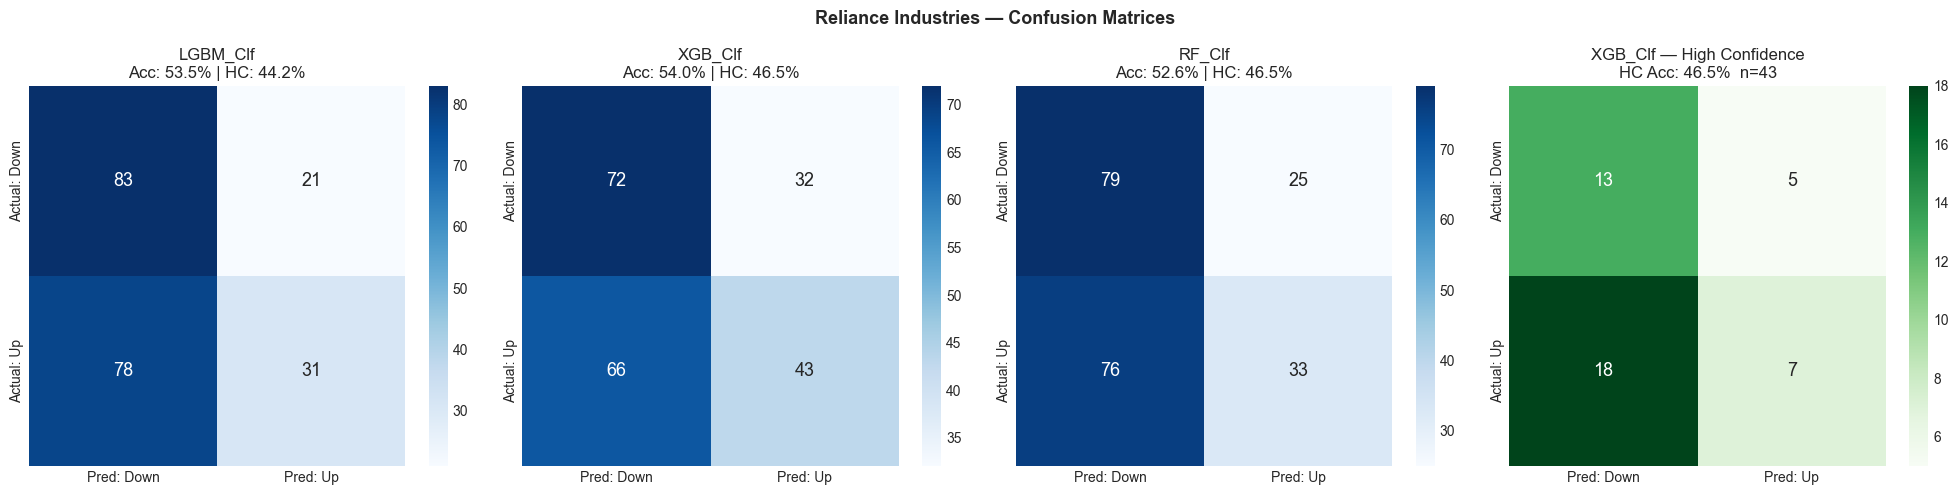


Detailed Report — XGB_Clf:
              precision    recall  f1-score   support

        Down       0.52      0.69      0.60       104
          Up       0.57      0.39      0.47       109

    accuracy                           0.54       213
   macro avg       0.55      0.54      0.53       213
weighted avg       0.55      0.54      0.53       213



In [148]:
# ── Confusion Matrices (Classifiers only) ────────────────────────

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Explicit classifier list (same kept models)
CLF_MODELS = ['LGBM_Clf', 'XGB_Clf', 'RF_Clf']
clf_present = [m for m in CLF_MODELS if m in results]

if len(clf_present) == 0:
    print("No classifier results found in `results`.")
else:
    n_clf = len(clf_present)

    # +1 for high-confidence panel
    fig, axes = plt.subplots(1, n_clf + 1, figsize=(5 * (n_clf + 1), 5))

    # Make axes always indexable (important when n_clf=1)
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = np.ravel(axes)

    # Regular confusion matrices for each classifier
    for idx, m in enumerate(clf_present):
        r = results[m]
        cm = confusion_matrix(y_test_bin, r['pred_bin'])
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
            xticklabels=['Pred: Down', 'Pred: Up'],
            yticklabels=['Actual: Down', 'Actual: Up'],
            annot_kws={'size': 13}
        )
        axes[idx].set_title(f'{m}\nAcc: {r["acc"]*100:.1f}% | HC: {r["acc_hc"]*100:.1f}%')

    # Best classifier by high-confidence accuracy
    best_clf = max(clf_present, key=lambda m: results[m].get('acc_hc', -np.inf))
    r_best = results[best_clf]

    hc_mask = r_best.get('hc_mask', None)
    if hc_mask is not None and np.sum(hc_mask) > 0:
        cm_hc = confusion_matrix(y_test_bin[hc_mask], r_best['pred_bin'][hc_mask])
        sns.heatmap(
            cm_hc, annot=True, fmt='d', cmap='Greens', ax=axes[-1],
            xticklabels=['Pred: Down', 'Pred: Up'],
            yticklabels=['Actual: Down', 'Actual: Up'],
            annot_kws={'size': 13}
        )
        axes[-1].set_title(
            f'{best_clf} — High Confidence\n'
            f'HC Acc: {r_best["acc_hc"]*100:.1f}%  n={int(np.sum(hc_mask))}'
        )
    else:
        axes[-1].axis('off')
        axes[-1].text(
            0.5, 0.5,
            f'{best_clf} — High Confidence\nNo HC predictions available',
            ha='center', va='center', fontsize=11
        )

    plt.suptitle(f'{STOCK_NAME} — Confusion Matrices', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'\nDetailed Report — {best_clf}:')
    print(classification_report(y_test_bin, r_best['pred_bin'], target_names=['Down', 'Up']))

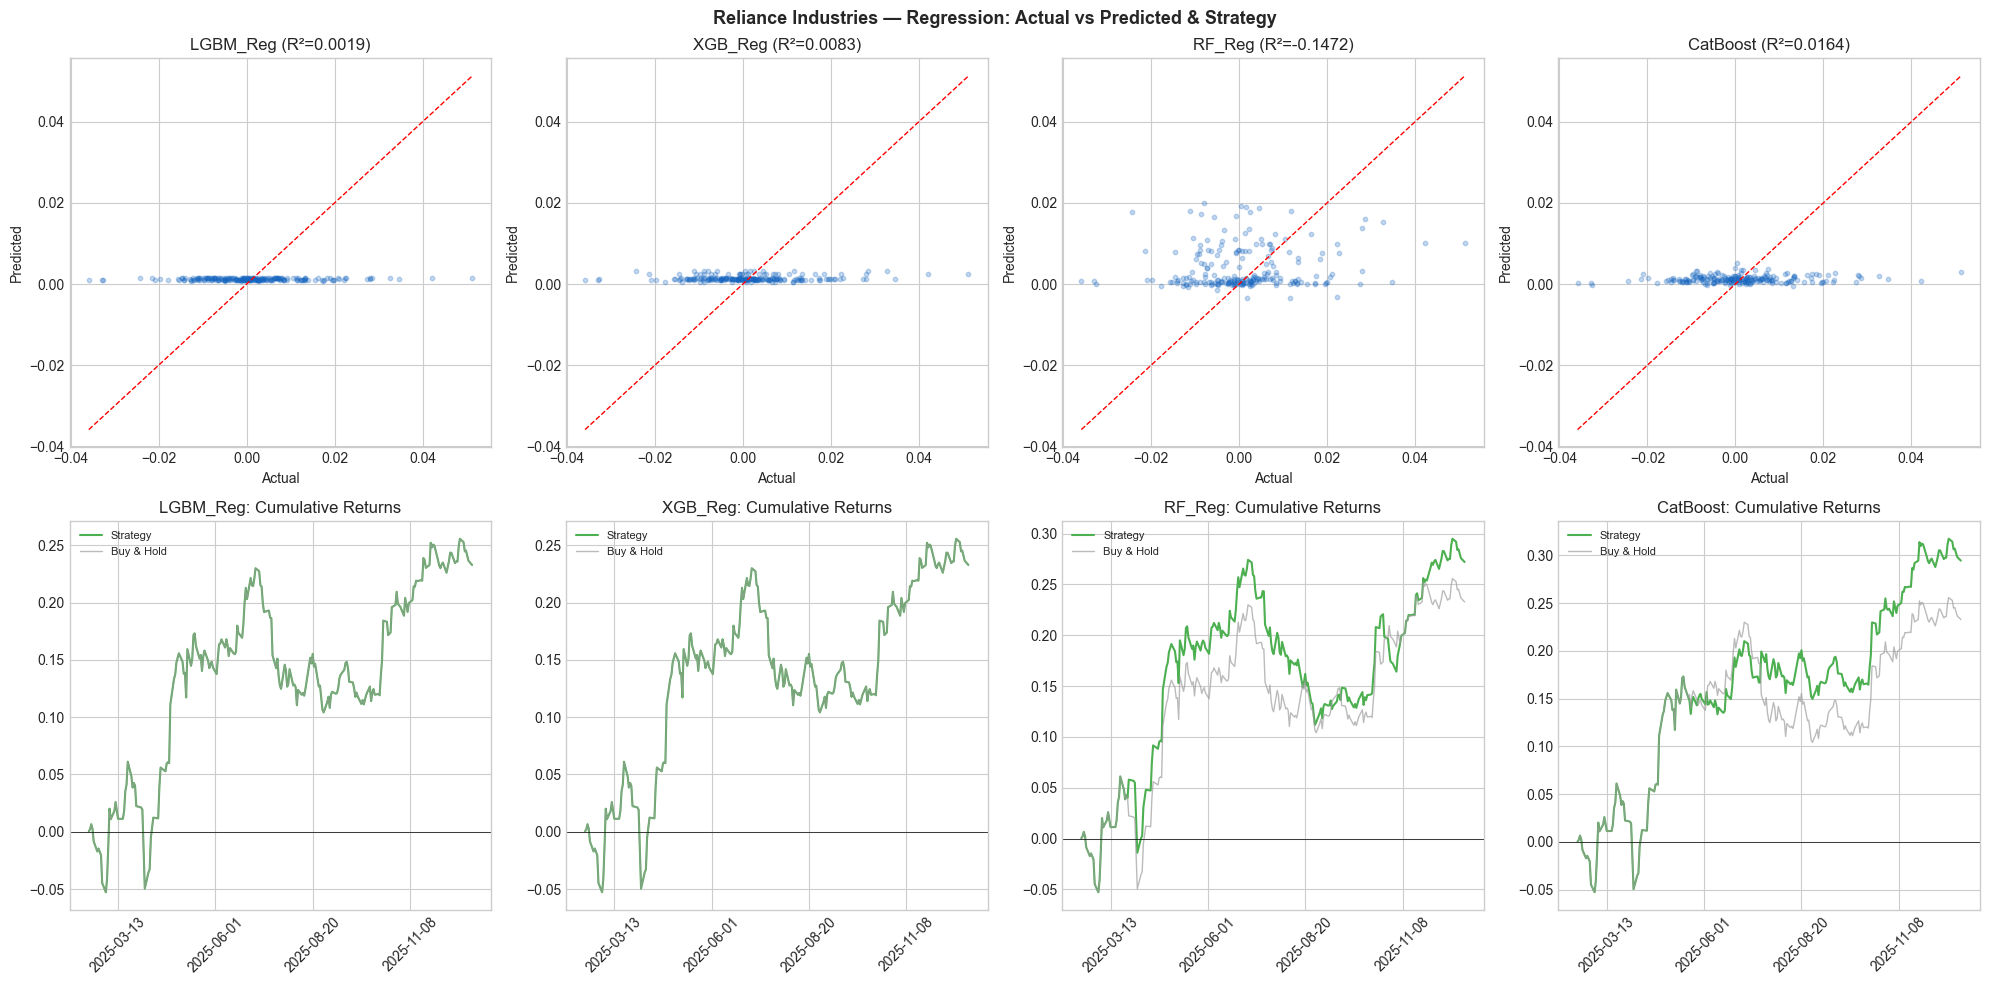

In [149]:
# ── Actual vs Predicted + Cumulative Strategy Returns ────────────

reg_plot = [m for m in ['LGBM_Reg', 'XGB_Reg', 'RF_Reg', 'CatBoost'] if m in results]

if len(reg_plot) == 0:
    print("No regression model results found in `results`.")
else:
    fig, axes = plt.subplots(2, len(reg_plot), figsize=(5 * len(reg_plot), 10))

    # Handle single-model case so axes[0, idx] indexing still works
    if len(reg_plot) == 1:
        axes = axes.reshape(2, 1)

    for idx, m in enumerate(reg_plot):
        r = results[m]
        pred = r['pred']

        # Scatter: Actual vs Predicted
        axes[0, idx].scatter(y_test_raw, pred, alpha=0.25, s=10, color='#1565C0')
        lims = [float(np.min(y_test_raw)), float(np.max(y_test_raw))]
        axes[0, idx].plot(lims, lims, 'r--', lw=1)
        axes[0, idx].set_xlabel('Actual')
        axes[0, idx].set_ylabel('Predicted')
        axes[0, idx].set_title(f'{m} (R²={r["r2"]:.4f})')

        # Cumulative returns (naive sign strategy)
        strat = np.sign(pred) * np.asarray(y_test_raw)
        axes[1, idx].plot(
            dates_test.values, np.cumsum(strat),
            label='Strategy', color='#4CAF50', lw=1.5
        )
        axes[1, idx].plot(
            dates_test.values, np.cumsum(np.asarray(y_test_raw)),
            label='Buy & Hold', color='#9E9E9E', lw=1, alpha=0.7
        )
        axes[1, idx].axhline(0, color='black', lw=0.5)
        axes[1, idx].set_title(f'{m}: Cumulative Returns')
        axes[1, idx].legend(fontsize=8)
        axes[1, idx].tick_params(axis='x', rotation=45)
        axes[1, idx].xaxis.set_major_locator(plt.MaxNLocator(5))

    plt.suptitle(
        f'{STOCK_NAME} — Regression: Actual vs Predicted & Strategy',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

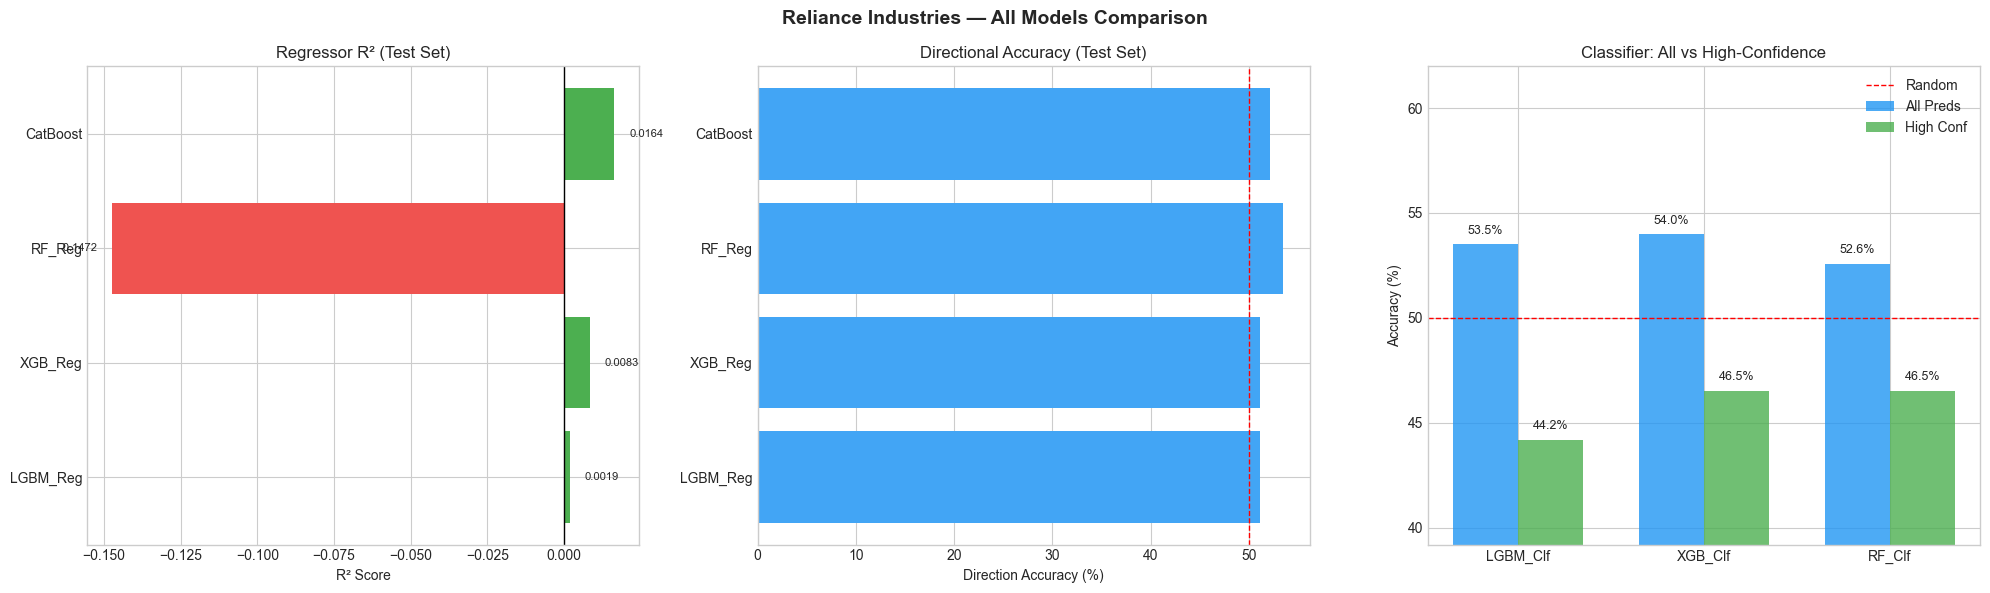

In [150]:
# ── Model Comparison Summary ─────────────────────────────────────
# Uses cleaned REG_MODELS / CLF_MODELS (no Ridge/Lasso/ElasticNet/ET_Reg)

import numpy as np
import matplotlib.pyplot as plt

reg_names = [m for m in REG_MODELS if m in results]
r2_vals   = [results[m]['r2'] * 1.0 for m in reg_names]
da_vals   = [results[m]['dir_acc'] * 100 for m in reg_names]

clf_names = [m for m in CLF_MODELS if m in results]
acc_vals  = [results[m]['acc'] * 100 for m in clf_names]
hc_vals   = [results[m]['acc_hc'] * 100 for m in clf_names]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ---------------- R² (Regressors) ----------------
if len(reg_names) > 0:
    colors_r2 = ['#4CAF50' if v > 0 else '#EF5350' for v in r2_vals]
    bars = axes[0].barh(reg_names, r2_vals, color=colors_r2)
    axes[0].axvline(0, color='black', lw=1)
    axes[0].set_xlabel('R² Score')
    axes[0].set_title('Regressor R² (Test Set)')

    # Better text placement for positive/negative values
    r2_span = (max(r2_vals) - min(r2_vals)) if len(r2_vals) > 0 else 0
    r2_pad = max(0.001, 0.03 * (r2_span if r2_span > 0 else 1))

    for bar, v in zip(bars, r2_vals):
        if v >= 0:
            x_text = bar.get_width() + r2_pad
            ha = 'left'
        else:
            x_text = bar.get_width() - r2_pad
            ha = 'right'
        axes[0].text(
            x_text,
            bar.get_y() + bar.get_height() / 2,
            f'{v:.4f}',
            va='center',
            ha=ha,
            fontsize=8
        )
else:
    axes[0].axis('off')
    axes[0].text(0.5, 0.5, 'No regressor results', ha='center', va='center', fontsize=11)

# ---------------- Direction Accuracy (Regressors) ----------------
if len(reg_names) > 0:
    axes[1].barh(reg_names, da_vals, color='#42A5F5')
    axes[1].axvline(50, color='red', ls='--', lw=1)
    axes[1].set_xlabel('Direction Accuracy (%)')
    axes[1].set_title('Directional Accuracy (Test Set)')
else:
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'No regressor results', ha='center', va='center', fontsize=11)

# ---------------- Classifier Accuracy ----------------
if len(clf_names) > 0:
    x = np.arange(len(clf_names))
    w = 0.35

    axes[2].bar(x - w / 2, acc_vals, w, label='All Preds', color='#2196F3', alpha=0.8)
    axes[2].bar(x + w / 2, hc_vals,  w, label='High Conf', color='#4CAF50', alpha=0.8)
    axes[2].axhline(50, color='red', ls='--', lw=1, label='Random')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(clf_names)
    axes[2].set_ylabel('Accuracy (%)')
    axes[2].set_title('Classifier: All vs High-Confidence')
    axes[2].legend()

    # Dynamic y-limits so labels don't clip
    y_max = max(acc_vals + hc_vals) if (len(acc_vals) + len(hc_vals)) > 0 else 100
    axes[2].set_ylim(min(40, max(0, min(acc_vals + hc_vals) - 5)), min(100, y_max + 8))

    for i, (a, h) in enumerate(zip(acc_vals, hc_vals)):
        axes[2].text(i - w / 2, a + 0.5, f'{a:.1f}%', ha='center', fontsize=9)
        axes[2].text(i + w / 2, h + 0.5, f'{h:.1f}%', ha='center', fontsize=9)
else:
    axes[2].axis('off')
    axes[2].text(0.5, 0.5, 'No classifier results', ha='center', va='center', fontsize=11)

plt.suptitle(f'{STOCK_NAME} — All Models Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()

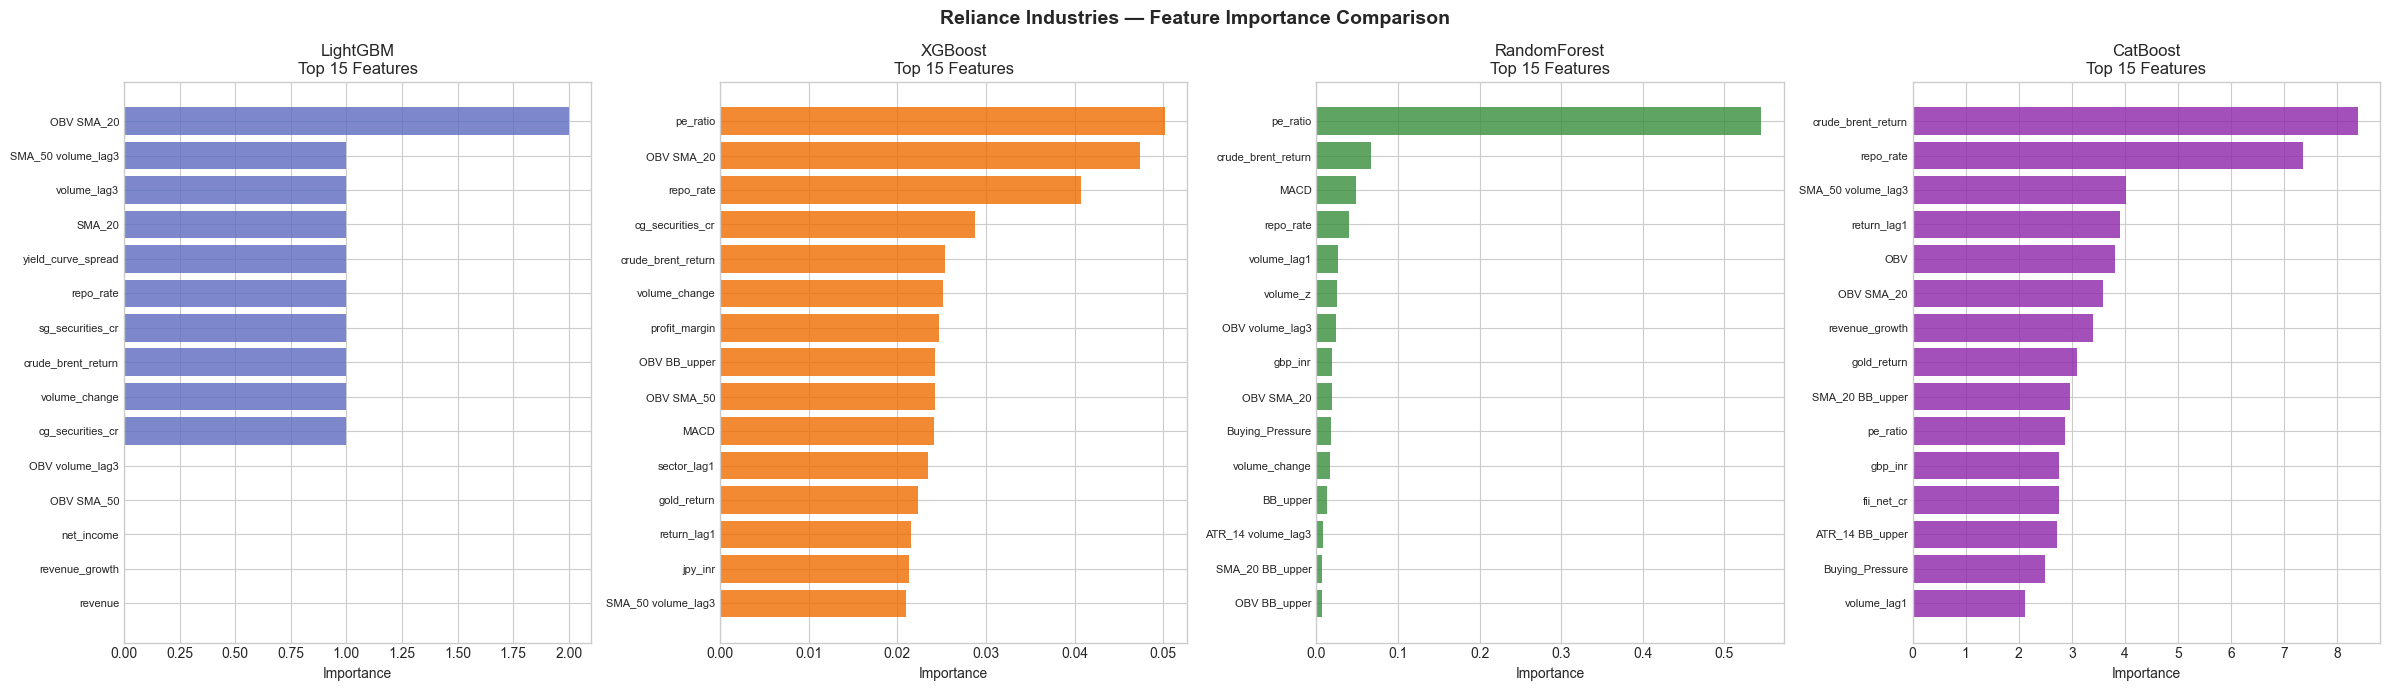

In [151]:
# ── Feature Importance (Tree Models) ────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Better to use actual training columns if available (avoids mismatch with ALL_FEATS)
feat_index = X_train.columns if hasattr(X_train, "columns") else ALL_FEATS

imp_pairs = []

if 'LGBM_Reg' in results and 'm_lgbm_reg' in globals():
    imp_pairs.append((
        'LightGBM',
        pd.Series(m_lgbm_reg.feature_importances_, index=feat_index)
    ))

if 'XGB_Reg' in results and 'm_xgb_reg' in globals():
    imp_pairs.append((
        'XGBoost',
        pd.Series(m_xgb_reg.feature_importances_, index=feat_index)
    ))

if 'RF_Reg' in results and 'm_rf_reg' in globals():
    imp_pairs.append((
        'RandomForest',
        pd.Series(m_rf_reg.feature_importances_, index=feat_index)
    ))

# Optional CatBoost
if 'CatBoost' in results and 'm_cat' in globals():
    try:
        cb_imp = m_cat.get_feature_importance()
        imp_pairs.append((
            'CatBoost',
            pd.Series(cb_imp, index=feat_index)
        ))
    except Exception as e:
        print(f"CatBoost feature importance skipped: {e}")

if len(imp_pairs) == 0:
    print("No tree-model feature importances available to plot.")
else:
    fig, axes = plt.subplots(1, len(imp_pairs), figsize=(6 * len(imp_pairs), 7))

    # Handle single subplot case
    if len(imp_pairs) == 1:
        axes = [axes]

    palette = ['#5C6BC0', '#EF6C00', '#388E3C', '#8E24AA']  # LGBM, XGB, RF, CatBoost

    for ax, (name, imp), clr in zip(axes, imp_pairs, palette):
        imp = imp.fillna(0)
        top = imp.sort_values(ascending=True).tail(15)

        ax.barh(range(len(top)), top.values, color=clr, alpha=0.8)
        ax.set_yticks(range(len(top)))
        ax.set_yticklabels(top.index, fontsize=8)
        ax.set_title(f'{name}\nTop 15 Features')
        ax.set_xlabel('Importance')

    plt.suptitle(f'{STOCK_NAME} — Feature Importance Comparison',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [152]:
# ============================================================
# SAVE TEST TARGETS + TEST PREDICTIONS WITH DATES TO CSV
# (uses your existing variables: results, dates_test, y_test_raw, etc.)
# ============================================================


# 1) Pick regression models that exist in your results dict
reg_candidates = [m for m in ['LGBM_Reg', 'XGB_Reg', 'RF_Reg', 'CatBoost'] if m in results]

if len(reg_candidates) == 0:
    raise ValueError("No regression models found in `results`. Run the tuning/test evaluation cell first.")

# 2) Automatically choose best regressor by lowest test RMSE
best_reg_model = min(reg_candidates, key=lambda m: results[m].get('rmse', np.inf))

# 3) Build output dataframe (date + actual targets)
out_df = pd.DataFrame({
    'date': pd.to_datetime(dates_test).reset_index(drop=True),
    'target_raw_return': pd.Series(y_test_raw).reset_index(drop=True)
})

# Optional target columns (only added if available)
if 'y_test_res' in globals():
    out_df['target_residualized'] = pd.Series(y_test_res).reset_index(drop=True)

if 'y_test_bin' in globals():
    out_df['target_direction_bin'] = pd.Series(y_test_bin).reset_index(drop=True)

# 4) Add best model predictions
best_pred = pd.Series(results[best_reg_model]['pred']).reset_index(drop=True)
out_df[f'pred_{best_reg_model}'] = best_pred
out_df[f'error_{best_reg_model}'] = out_df['target_raw_return'] - best_pred
out_df[f'pred_sign_{best_reg_model}'] = np.sign(best_pred).astype(int)

# 5) (Optional) Also save all regressor predictions in the same file
for m in reg_candidates:
    if m == best_reg_model:
        continue
    if 'pred' in results[m]:
        out_df[f'pred_{m}'] = pd.Series(results[m]['pred']).reset_index(drop=True)

# 6) Format date and save
out_df['date'] = out_df['date'].dt.strftime('%Y-%m-%d')

stock_name = globals().get('STOCK_NAME', 'STOCK')
csv_name = f"{stock_name}_test_targets_predictions_with_dates.csv"
out_df.to_csv(csv_name, index=False)

print(f"Saved: {csv_name}")
print(f"Best regressor (by test RMSE): {best_reg_model} | RMSE = {results[best_reg_model].get('rmse', np.nan):.6f}")
display(out_df.head())

Saved: Reliance Industries_test_targets_predictions_with_dates.csv
Best regressor (by test RMSE): CatBoost | RMSE = 0.011847


,date,target_raw_return,target_residualized,target_direction_bin,pred_CatBoost,error_CatBoost,pred_sign_CatBoost,pred_LGBM_Reg,pred_XGB_Reg,pred_RF_Reg
0,2025-02-17,0.000408,-0.003213,0,0.005133,-0.004725,1,0.001421,0.003164,0.019201
1,2025-02-18,0.001671,-0.009593,0,0.003539,-0.001868,1,0.001421,0.003164,0.018996
2,2025-02-19,0.004511,-0.013630,0,0.003576,0.000936,1,0.001421,0.003164,0.018708
3,2025-02-20,-0.003941,0.001666,1,0.002680,-0.006621,1,0.001421,0.001550,0.010491
4,2025-02-21,-0.011135,0.000044,1,0.001199,-0.012334,1,0.001421,0.003164,0.018002
